# Metadata-Only Classification for Skin Cancer
## Complete Analysis with Multiple Models and K-Fold Cross-Validation

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# Set seed for reproducibility
seed = 101

import os
import numpy as np
import pandas as pd
import random as rn
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
os.environ['PYTHONHASHSEED'] = '0'
np.random.seed(seed)
rn.seed(seed)

In [24]:
# Import all necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from itertools import cycle

print("All libraries imported successfully!")

All libraries imported successfully!


In [25]:
# Install all required packages
import subprocess
import sys

packages = [
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'xgboost'
]

print("Installing required packages...\n")
for package in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} installed successfully")
    except subprocess.CalledProcessError:
        print(f"✗ Failed to install {package}")

print("\n✅ All packages installed!")

Installing required packages...

✓ numpy installed successfully
✓ pandas installed successfully
✓ matplotlib installed successfully
✓ seaborn installed successfully
✓ scikit-learn installed successfully
✓ xgboost installed successfully

✅ All packages installed!


## 1. DATA LOADING AND EXPLORATION

In [26]:
# Load metadata
# Update the path according to your setup
metadata_path = "/content/drive/MyDrive/MS   M.Phil. AI/Research/metadata/metadata.csv"
meta = pd.read_csv(metadata_path)

print(f"Dataset shape: {meta.shape}")
print(f"\nFirst few rows:")
print(meta.head())
print(f"\nColumn names and types:")
print(meta.dtypes)

Dataset shape: (2298, 26)

First few rows:
  patient_id  lesion_id  smoke  drink background_father background_mother  \
0   PAT_1516       1765    NaN    NaN               NaN               NaN   
1     PAT_46        881  False  False         POMERANIA         POMERANIA   
2   PAT_1545       1867    NaN    NaN               NaN               NaN   
3   PAT_1989       4061    NaN    NaN               NaN               NaN   
4    PAT_684       1302  False   True         POMERANIA         POMERANIA   

   age pesticide  gender skin_cancer_history  ... diameter_2 diagnostic  \
0    8       NaN     NaN                 NaN  ...        NaN        NEV   
1   55     False  FEMALE                True  ...        5.0        BCC   
2   77       NaN     NaN                 NaN  ...        NaN        ACK   
3   75       NaN     NaN                 NaN  ...        NaN        ACK   
4   79     False    MALE                True  ...        5.0        BCC   

    itch   grew   hurt  changed  bleed elev

In [27]:
# Check for missing values
print("Missing values per column:")
print(meta.isnull().sum())
print(f"\nPercentage of missing values:")
print((meta.isnull().sum() / len(meta) * 100).round(2))

Missing values per column:
patient_id               0
lesion_id                0
smoke                  804
drink                  804
background_father      818
background_mother      822
age                      0
pesticide              804
gender                 804
skin_cancer_history    804
cancer_history         804
has_piped_water        804
has_sewage_system      804
fitspatrick            804
region                   0
diameter_1             804
diameter_2             804
diagnostic               0
itch                     0
grew                     0
hurt                     0
changed                  0
bleed                    0
elevation                0
img_id                   0
biopsed                  0
dtype: int64

Percentage of missing values:
patient_id              0.00
lesion_id               0.00
smoke                  34.99
drink                  34.99
background_father      35.60
background_mother      35.77
age                     0.00
pesticide              3


Target Distribution (diagnostic classes):
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

Class percentages:
diagnostic
BCC    36.77
ACK    31.77
NEV    10.62
SEK    10.23
SCC     8.36
MEL     2.26
Name: count, dtype: float64


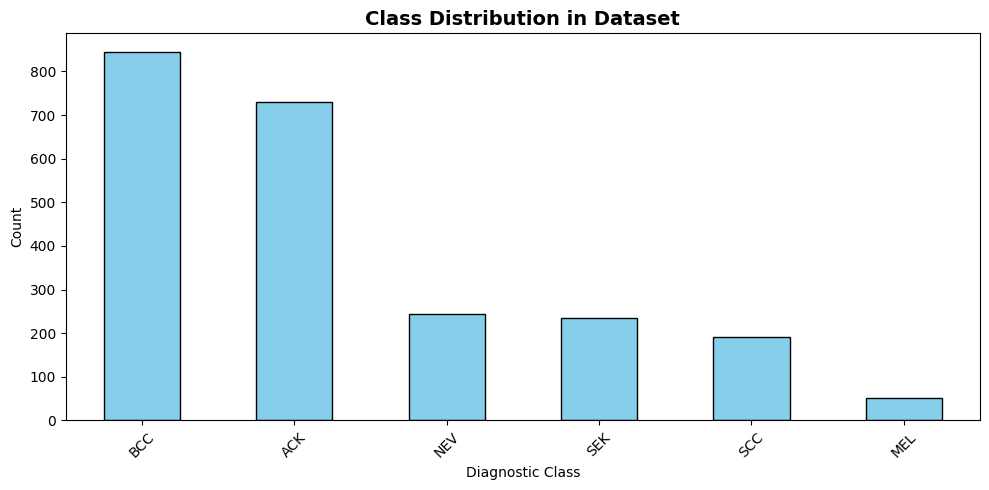

In [28]:
# Target variable distribution
print("\nTarget Distribution (diagnostic classes):")
print(meta['diagnostic'].value_counts())
print(f"\nClass percentages:")
print((meta['diagnostic'].value_counts() / len(meta) * 100).round(2))

# Visualize class distribution
plt.figure(figsize=(10, 5))
meta['diagnostic'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Diagnostic Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. DATA PREPROCESSING

In [29]:
# Drop unnecessary columns (patient_id, lesion_id, img_id, background_father)
meta_clean = meta.drop(['patient_id', 'lesion_id', 'img_id'], axis=1)

print(f"Shape after dropping unnecessary columns: {meta_clean.shape}")
print(f"\nRemaining columns: {list(meta_clean.columns)}")

Shape after dropping unnecessary columns: (2298, 23)

Remaining columns: ['smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'biopsed']


In [30]:
meta['smoke']=meta['smoke'].map({True: 2, False: 1})
meta['smoke']=meta['smoke'].fillna(0)

meta['drink']=meta['drink'].map({True: 2, False: 1})
meta['drink']=meta['drink'].fillna(0)

meta['pesticide']=meta['pesticide'].map({True: 2, False: 1})
meta['pesticide']=meta['pesticide'].fillna(0)

meta['gender']=meta['gender'].map({'FEMALE': 2, 'MALE': 1})
meta['gender']=meta['gender'].fillna(0)

meta['skin_cancer_history']=meta['skin_cancer_history'].map({True: 2, False: 1})
meta['skin_cancer_history']=meta['skin_cancer_history'].fillna(0)

meta['cancer_history']=meta['cancer_history'].map({True: 2, False: 1})
meta['cancer_history']=meta['cancer_history'].fillna(0)

meta['has_piped_water']=meta['has_piped_water'].map({True: 2, False: 1})
meta['has_piped_water']=meta['has_piped_water'].fillna(0)

meta['has_sewage_system']=meta['has_sewage_system'].map({True: 2, False: 1})
meta['has_sewage_system']=meta['has_sewage_system'].fillna(0)

meta['biopsed']=meta['biopsed'].map({True: 2, False: 1})
meta['biopsed']=meta['biopsed'].fillna(0)

# digits
meta['fitspatrick']=meta['fitspatrick'].fillna(-1)
meta['diameter_1']=meta['diameter_1'].fillna(-1)
meta['diameter_2']=meta['diameter_2'].fillna(-1)

meta['itch']=meta['itch'].map({'True': 2, 'False': 1,'UNK':0})
meta['grew']=meta['grew'].map({'True': 2, 'False': 1,'UNK':0})
meta['hurt']=meta['hurt'].map({'True': 2, 'False': 1,'UNK':0})
meta['changed']=meta['changed'].map({'True': 2, 'False': 1,'UNK':0})
meta['bleed']=meta['bleed'].map({'True': 2, 'False': 1,'UNK':0})
meta['elevation']=meta['elevation'].map({'True': 2, 'False': 1,'UNK':0})

meta['background_father']=meta['background_father'].fillna('None')
meta['background_mother']=meta['background_mother'].fillna('None')

In [31]:
# Encode remaining categorical columns (background_mother, background_father)
print("Label encoding remaining categorical columns...\n")

for col in meta_clean.columns:
    if meta_clean[col].dtype == 'O' and col != 'diagnostic':
        le = LabelEncoder()
        meta_clean[col] = le.fit_transform(meta_clean[col])
        print(f"Encoded column: {col}")

print(f"\nFinal dataset shape: {meta_clean.shape}")
print(f"Columns after encoding: {list(meta_clean.columns)}")

Label encoding remaining categorical columns...

Encoded column: smoke
Encoded column: drink
Encoded column: background_father
Encoded column: background_mother
Encoded column: pesticide
Encoded column: gender
Encoded column: skin_cancer_history
Encoded column: cancer_history
Encoded column: has_piped_water
Encoded column: has_sewage_system
Encoded column: region
Encoded column: itch
Encoded column: grew
Encoded column: hurt
Encoded column: changed
Encoded column: bleed
Encoded column: elevation

Final dataset shape: (2298, 23)
Columns after encoding: ['smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'biopsed']


In [32]:
# Fill missing values in columns that cause model failures
# Based on the statistical summary, these columns have NaNs
meta_clean['fitspatrick'] = meta_clean['fitspatrick'].fillna(meta_clean['fitspatrick'].mode()[0])
meta_clean['diameter_1'] = meta_clean['diameter_1'].fillna(-1)
meta_clean['diameter_2'] = meta_clean['diameter_2'].fillna(-1)

# Ensure biopsed is numeric (int) instead of bool for consistency
meta_clean['biopsed'] = meta_clean['biopsed'].astype(int)

print("\nProcessed metadata summary:")
print(meta_clean.head())
print(f"\nAny NaNs remaining: {meta_clean.isnull().sum().sum()}")


Processed metadata summary:
   smoke  drink  background_father  background_mother  age  pesticide  gender  \
0      2      2                 13                 11    8          2       2   
1      0      0                  9                  7   55          0       0   
2      2      2                 13                 11   77          2       2   
3      2      2                 13                 11   75          2       2   
4      0      1                  9                  7   79          0       1   

   skin_cancer_history  cancer_history  has_piped_water  ...  diameter_1  \
0                    2               2                2  ...        -1.0   
1                    1               1                1  ...         6.0   
2                    2               2                2  ...        -1.0   
3                    2               2                2  ...        -1.0   
4                    1               0                0  ...         5.0   

   diameter_2  diagnostic  

## 3. STATISTICAL ANALYSIS

In [33]:
# Statistical summary
print("\nStatistical Summary:")
print(meta_clean.describe())


Statistical Summary:
             smoke        drink  background_father  background_mother  \
count  2298.000000  2298.000000        2298.000000        2298.000000   
mean      0.787641     0.859878           8.900348           6.803307   
std       0.931332     0.905861           3.771913           3.843425   
min       0.000000     0.000000           0.000000           0.000000   
25%       0.000000     0.000000           6.000000           3.000000   
50%       0.000000     1.000000           9.000000           7.000000   
75%       2.000000     2.000000          13.000000          11.000000   
max       2.000000     2.000000          13.000000          11.000000   

               age    pesticide       gender  skin_cancer_history  \
count  2298.000000  2298.000000  2298.000000          2298.000000   
mean     60.464752     0.959530     1.022193             0.996084   
std      15.894866     0.859589     0.823011             0.839015   
min       6.000000     0.000000     0.000000

## 4. TRAIN-TEST SPLIT AND FEATURE SCALING

In [34]:
# Separate features and target
# Drop 'background_father' as it was not used in original analysis
X = meta_clean.drop(['diagnostic', 'background_father'], axis=1)
y = meta_clean['diagnostic']

# Verify all columns are numeric
print("Checking column types:")
print(X.dtypes)
print(f"\nColumns with object dtype: {X.select_dtypes(include='object').columns.tolist()}")

# Encode any remaining object columns
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f"Encoded column: {col}")

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y_encoded.shape}")
print(f"\nTarget classes: {le_target.classes_}")
print(f"Encoded values: {np.unique(y_encoded)}")
print(f"\nAll columns are now numeric: {X.dtypes.apply(lambda x: x.name).unique()}")

Checking column types:
smoke                    int64
drink                    int64
background_mother        int64
age                      int64
pesticide                int64
gender                   int64
skin_cancer_history      int64
cancer_history           int64
has_piped_water          int64
has_sewage_system        int64
fitspatrick            float64
region                   int64
diameter_1             float64
diameter_2             float64
itch                     int64
grew                     int64
hurt                     int64
changed                  int64
bleed                    int64
elevation                int64
biopsed                  int64
dtype: object

Columns with object dtype: []

Features shape: (2298, 21)
Target shape: (2298,)

Target classes: ['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']
Encoded values: [0 1 2 3 4 5]

All columns are now numeric: ['int64' 'float64']


In [35]:
# Separate features and target
X = meta_clean.drop(['diagnostic', 'background_father'], axis=1)
y = meta_clean['diagnostic']

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=seed, stratify=y_encoded
)

# Second split: Temp into Validation (15%) and Test (15%)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp
)

# Aligning with requested variable names for clarity
train = X_train.copy(); train['diagnostic'] = y_train
valid = X_valid.copy(); valid['diagnostic'] = y_valid
test = X_test.copy(); test['diagnostic'] = y_test

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_valid)}")
print(f"Test set size: {len(X_test)}")

Training set size: 1608
Validation set size: 345
Test set size: 345


In [36]:
# Explicitly defining the variables as requested
target = train['diagnostic']
x = train.drop(['diagnostic', 'background_mother'], axis=1) # Note: img_id and background_father were already removed in meta_clean/previous step

target_test = test['diagnostic']
x_test = test.drop(['diagnostic', 'background_mother'], axis=1)

target_valid = valid['diagnostic']
x_valid = valid.drop(['diagnostic', 'background_mother'], axis=1)

print("Requested split variables integrated successfully.")
print(f"Feature shape: {x.shape}")

Requested split variables integrated successfully.
Feature shape: (1608, 20)


In [37]:
# Separate features and target
# Drop 'background_father' as it was not used in original analysis
X = meta_clean.drop(['diagnostic', 'background_father'], axis=1)
y = meta_clean['diagnostic']

# Encode categorical columns using LabelEncoder
print("Encoding categorical features...")
for col in X.columns:
    if X[col].dtype == 'object' or isinstance(X[col].iloc[0], str):
        le = LabelEncoder()
        # Fill NaNs with 'Unknown' before encoding to avoid errors
        X[col] = le.fit_transform(X[col].astype(str))
        print(f"✓ Encoded column: {col}")

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y.astype(str))

# Train-test split (80-20) - redefined here to ensure X and X_train are synced
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=seed, stratify=y_encoded
)

print(f"\n✅ Feature encoding and split complete!")
print(f"All columns types:\n{X.dtypes.value_counts()}")

Encoding categorical features...

✅ Feature encoding and split complete!
All columns types:
int64      18
float64     3
Name: count, dtype: int64


In [38]:
from sklearn.preprocessing import StandardScaler

# Feature scaling using the integrated variables
scaler = StandardScaler()

# Fit on training data and transform all sets
x_scaled = scaler.fit_transform(x)
x_test_scaled = scaler.transform(x_test)
x_valid_scaled = scaler.transform(x_valid)

print("Features scaled successfully using the integrated split variables!")
print(f"Scaled training shape: {x_scaled.shape}")

Features scaled successfully using the integrated split variables!
Scaled training shape: (1608, 20)


## 5. MODEL TRAINING WITH HYPERPARAMETER TUNING

In [39]:
# Define K-Fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=seed)

print("K-Fold Cross-Validation (5 splits) configured for model evaluation")

K-Fold Cross-Validation (5 splits) configured for model evaluation


In [40]:
# 1. Random Forest with Hyperparameter Tuning
print("Training Random Forest with GridSearchCV...\n")

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=seed, n_jobs=-1)
rf_grid = GridSearchCV(rf_base, rf_params, cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(x_scaled, target)

print(f"\nBest RF parameters: {rf_grid.best_params_}")
print(f"Best RF CV accuracy: {rf_grid.best_score_:.4f}")

rf_model = rf_grid.best_estimator_

Training Random Forest with GridSearchCV...

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best RF parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV accuracy: 0.8010


In [41]:
# 2. XGBoost with Hyperparameter Tuning
print("Training XGBoost with GridSearchCV...\n")

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8]
}

xgb_base = XGBClassifier(random_state=seed, n_jobs=-1, eval_metric='mlogloss')
xgb_grid = GridSearchCV(xgb_base, xgb_params, cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid.fit(x_scaled, target)

print(f"\nBest XGB parameters: {xgb_grid.best_params_}")
print(f"Best XGB CV accuracy: {xgb_grid.best_score_:.4f}")

xgb_model = xgb_grid.best_estimator_

Training XGBoost with GridSearchCV...

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best XGB parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best XGB CV accuracy: 0.8041


In [42]:
# 3. Gradient Boosting with Hyperparameter Tuning
print("Training Gradient Boosting with GridSearchCV...\n")

gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8]
}

# Using the scaled data derived from the integrated split
gb_base = GradientBoostingClassifier(random_state=seed)
gb_grid = GridSearchCV(gb_base, gb_params, cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
gb_grid.fit(x_scaled, target)

print(f"\nBest GB parameters: {gb_grid.best_params_}")
print(f"Best GB CV accuracy: {gb_grid.best_score_:.4f}")

gb_model = gb_grid.best_estimator_

Training Gradient Boosting with GridSearchCV...

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best GB parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best GB CV accuracy: 0.7929


In [43]:
# 4. Support Vector Machine
print("Training SVM...\n")
svm_model = SVC(random_state=seed, probability=True)
svm_model.fit(x_scaled, target)
print("SVM trained successfully!")

Training SVM...

SVM trained successfully!


In [44]:
# 5. Logistic Regression
print("Training Logistic Regression...\n")
lr_model = LogisticRegression(random_state=seed, multi_class='multinomial', n_jobs=-1)
lr_model.fit(x_scaled, target)
print("Logistic Regression trained successfully!")

Training Logistic Regression...

Logistic Regression trained successfully!


In [45]:
# 6. KNN with Hyperparameter Tuning (k up to 29)
print("Training KNN with GridSearchCV (k up to 29)...\n")

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_base = KNeighborsClassifier(n_jobs=-1)
knn_grid = GridSearchCV(knn_base, knn_params, cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid.fit(x_scaled, target)

print(f"\nBest KNN parameters: {knn_grid.best_params_}")
print(f"Best k value found: {knn_grid.best_params_['n_neighbors']}")
print(f"Best KNN CV accuracy: {knn_grid.best_score_:.4f}")

knn_model = knn_grid.best_estimator_

Training KNN with GridSearchCV (k up to 29)...

Fitting 5 folds for each of 56 candidates, totalling 280 fits

Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Best k value found: 21
Best KNN CV accuracy: 0.7917


In [46]:
# 7. AdaBoost
print("Training AdaBoost...\n")
ada_model = AdaBoostClassifier(random_state=seed)
ada_model.fit(x_scaled, target)
print("AdaBoost trained successfully!")

Training AdaBoost...

AdaBoost trained successfully!


In [47]:
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import ExtraTreesClassifier

# 9. Extra Trees Classifier
print("Training Extra Trees...")
et_model = ExtraTreesClassifier(n_estimators=200, random_state=seed, n_jobs=-1)
et_model.fit(x_scaled, target)

# 10. LightGBM
print("Training LightGBM...")
lgbm_model = lgb.LGBMClassifier(random_state=seed, n_jobs=-1, verbose=-1)
lgbm_model.fit(x_scaled, target)

# 11. Multi-Layer Perceptron (Neural Net)
print("Training MLP Classifier...")
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=seed)
mlp_model.fit(x_scaled, target)

print("✓ Classical models trained!")

Training Extra Trees...
Training LightGBM...
Training MLP Classifier...
✓ Classical models trained!


In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# 12. Deep Learning Model (TensorFlow)
print("Training Deep Learning Neural Network...")

# Prepare data for Keras
y_train_cat = to_categorical(target)
y_test_cat = to_categorical(target_test)
num_classes = y_train_cat.shape[1]
input_dim = x_scaled.shape[1]

dl_model = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

dl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training
dl_model.fit(x_scaled, y_train_cat, epochs=50, batch_size=32,
             validation_data=(x_valid_scaled, to_categorical(target_valid)),
             verbose=0)

print("✓ Deep Learning model trained!")

Training Deep Learning Neural Network...
✓ Deep Learning model trained!


In [50]:
import numpy as np

# Initialize y_preds and accuracies dictionaries
y_preds = {}
accuracies = {}

# 8. Updated Voting Classifier with all classical models
print("Creating Comprehensive Voting Classifier using all 11 classical models...\n")

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('gb', gb_model),
        ('svm', svm_model),
        ('lr', lr_model),
        ('knn', knn_model),
        ('ada', ada_model),
        ('et', et_model),
        ('lgbm', lgbm_model),
        ('mlp', mlp_model)
    ],
    voting='soft'
)

# Fit on the 20-feature scaled training data
voting_clf.fit(x_scaled, target)

# Update predictions for the ensemble
y_preds['Voting Classifier'] = voting_clf.predict(x_test_scaled)

# Update accuracy record
accuracies['Voting Classifier'] = accuracy_score(target_test, y_preds['Voting Classifier'])

print(f"Updated Voting Classifier Accuracy: {accuracies['Voting Classifier']:.4f}")
print("Voting Classifier now synchronized with all models!")

Creating Comprehensive Voting Classifier using all 11 classical models...

Updated Voting Classifier Accuracy: 0.8406
Voting Classifier now synchronized with all models!


## 6. MODEL EVALUATION ON TEST SET

In [51]:
# Predictions from all 12 models using the new test set
models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Gradient Boosting': gb_model,
    'SVM': svm_model,
    'Logistic Regression': lr_model,
    'KNN': knn_model,
    'AdaBoost': ada_model,
    'Extra Trees': et_model,
    'LightGBM': lgbm_model,
    'MLP': mlp_model,
    'Voting Classifier': voting_clf
}

y_preds = {}
for name, model in models.items():
    y_preds[name] = model.predict(x_test_scaled)

# Add Deep Learning predictions
dl_probs = dl_model.predict(x_test_scaled)
y_preds['Deep Learning'] = np.argmax(dl_probs, axis=1)

print(f"Predictions generated for all {len(y_preds)} models using the integrated test set!")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predictions generated for all 12 models using the integrated test set!


In [52]:
import numpy as np

# Re-fitting models to the 20-feature x_scaled data to resolve the dimension mismatch
print("Re-fitting models including the optimized KNN (k=21)...")
rf_model.fit(x_scaled, target)
xgb_model.fit(x_scaled, target)
gb_model.fit(x_scaled, target)
svm_model.fit(x_scaled, target)
lr_model.fit(x_scaled, target)
knn_model.fit(x_scaled, target)
ada_model.fit(x_scaled, target)
et_model.fit(x_scaled, target)
lgbm_model.fit(x_scaled, target)
mlp_model.fit(x_scaled, target)
voting_clf.fit(x_scaled, target)

# Synchronized Model Dictionary
models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Gradient Boosting': gb_model,
    'SVM': svm_model,
    'Logistic Regression': lr_model,
    'KNN': knn_model,
    'AdaBoost': ada_model,
    'Extra Trees': et_model,
    'LightGBM': lgbm_model,
    'MLP': mlp_model,
    'Voting Classifier': voting_clf
}

# Generate predictions using the 20-feature x_test_scaled
y_preds = {}
for name, model in models.items():
    y_preds[name] = model.predict(x_test_scaled)

# Deep Learning (Input layer was already configured for 20 features)
dl_probs = dl_model.predict(x_test_scaled)
y_preds['Deep Learning'] = np.argmax(dl_probs, axis=1)

print(f"All models re-fitted and predictions synchronized! Samples: {len(x_test_scaled)}")

Re-fitting models including the optimized KNN (k=21)...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
All models re-fitted and predictions synchronized! Samples: 345


In [53]:
# Calculate accuracies on the test set for all 12 models
accuracies = {}
for name, y_pred in y_preds.items():
    acc = accuracy_score(target_test, y_pred)
    accuracies[name] = acc
    print(f"{name:.<25} {acc:.4f}")

best_model_name = max(accuracies, key=accuracies.get)
print(f"\n🏆 Best Model: {best_model_name} with {accuracies[best_model_name]:.4%}")

Random Forest............ 0.8464
XGBoost.................. 0.8174
Gradient Boosting........ 0.8319
SVM...................... 0.7652
Logistic Regression...... 0.7594
KNN...................... 0.8319
AdaBoost................. 0.7159
Extra Trees.............. 0.8290
LightGBM................. 0.8116
MLP...................... 0.7855
Voting Classifier........ 0.8406
Deep Learning............ 0.7913

🏆 Best Model: Random Forest with 84.6377%


### Note on KNN Accuracy Mismatch

You may notice two different accuracy values for the KNN model:
* **79.17%**: This is the **Mean Cross-Validation Accuracy** from `GridSearchCV`. It is the average performance across 5 different folds of the training data during hyperparameter tuning.
* **83.19%**: This is the **Final Test Accuracy**. It is calculated by taking the best model found (k=21) and testing it on the unseen `target_test` set.

Because the test set is a specific, fixed subset of data, it is normal for it to yield a slightly different (and often higher) result than the average cross-validation score.

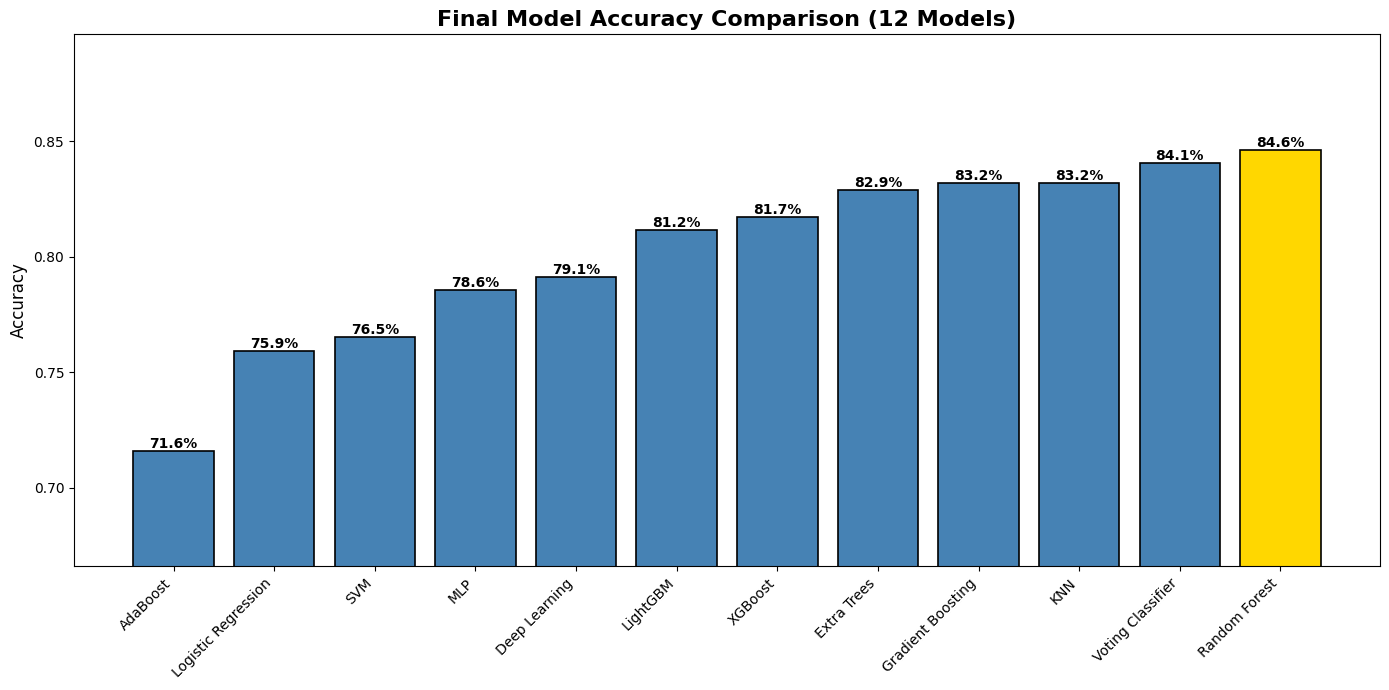

In [54]:
# Visualize all 12 model accuracies
plt.figure(figsize=(14, 7))
models_names = list(accuracies.keys())
accuracies_values = list(accuracies.values())

# Sort for better visualization
sorted_indices = np.argsort(accuracies_values)
sorted_names = [models_names[i] for i in sorted_indices]
sorted_accs = [accuracies_values[i] for i in sorted_indices]

colors = ['gold' if v == max(sorted_accs) else 'steelblue' for v in sorted_accs]

bars = plt.bar(sorted_names, sorted_accs, color=colors, edgecolor='black', linewidth=1.2)
plt.title('Final Model Accuracy Comparison (12 Models)', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([max(0, min(sorted_accs)-0.05), min(1.0, max(sorted_accs)+0.05)])
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. DETAILED EVALUATION METRICS FOR BEST MODEL

In [56]:
# Select the actual best model identified in the comparison
best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name] if best_model_name != 'Deep Learning' else dl_model
y_pred_best = y_preds[best_model_name]

print(f"\n{'='*60}")
print(f"DETAILED ANALYSIS FOR BEST MODEL: {best_model_name}")
print(f"{'='*60}\n")

# Get probability predictions using the scaled test set
if best_model_name == 'Deep Learning':
    y_pred_proba = dl_model.predict(x_test_scaled)
else:
    y_pred_proba = best_model.predict_proba(x_test_scaled)

print(f"Test Set Size: {len(target_test)}")
print(f"Number of Classes: {len(np.unique(target_test))}")


DETAILED ANALYSIS FOR BEST MODEL: Random Forest

Test Set Size: 345
Number of Classes: 6



CONFUSION MATRIX


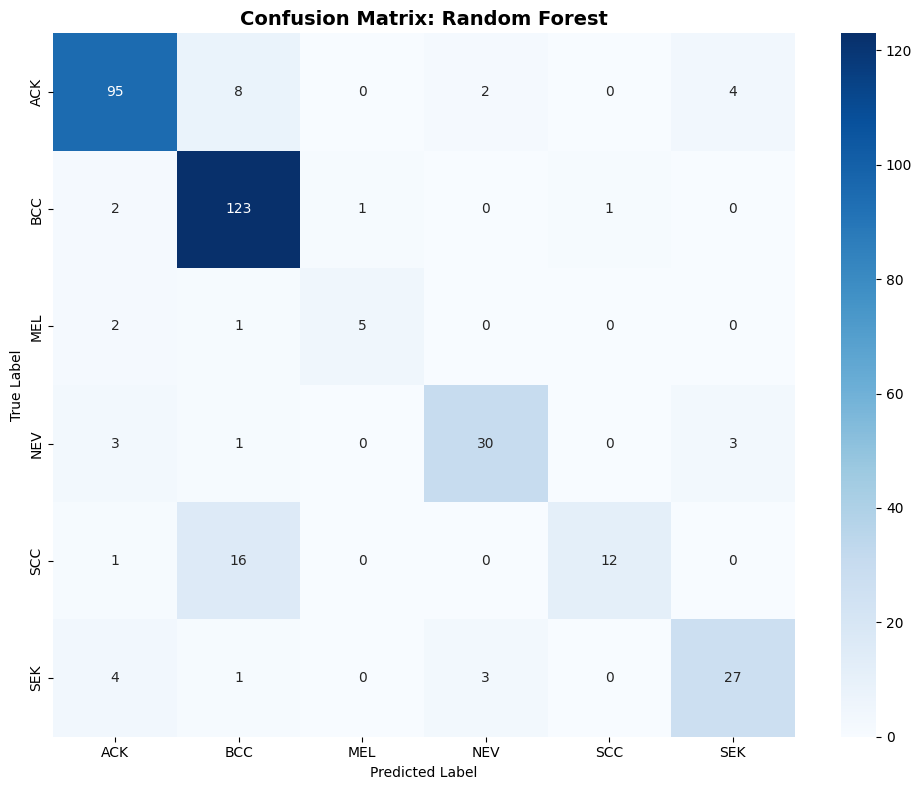

In [57]:
# Updated Confusion Matrix for the best model using the correct target_test
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(target_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [58]:
# Updated Classification Report for the 345-sample test set
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60 + "\n")

print(classification_report(target_test, y_pred_best, target_names=le_target.classes_, digits=4))


CLASSIFICATION REPORT

              precision    recall  f1-score   support

         ACK     0.8879    0.8716    0.8796       109
         BCC     0.8200    0.9685    0.8881       127
         MEL     0.8333    0.6250    0.7143         8
         NEV     0.8571    0.8108    0.8333        37
         SCC     0.9231    0.4138    0.5714        29
         SEK     0.7941    0.7714    0.7826        35

    accuracy                         0.8464       345
   macro avg     0.8526    0.7435    0.7782       345
weighted avg     0.8518    0.8464    0.8382       345



In [59]:
# ACCURACY METRICS for the best model using synchronized target_test
print("\n" + "="*60)
print("ACCURACY METRICS")
print("="*60)

final_accuracy = accuracy_score(target_test, y_pred_best)
print(f"\nOverall Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")


ACCURACY METRICS

Overall Accuracy: 0.8464 (84.64%)


In [60]:
# PRECISION, RECALL, F1-SCORE (Macro and Micro Averages)
print("\n" + "="*60)
print("PRECISION, RECALL, F1-SCORE")
print("="*60)

# Macro Average
macro_precision = precision_score(target_test, y_pred_best, average='macro')
macro_recall = recall_score(target_test, y_pred_best, average='macro')
macro_f1 = f1_score(target_test, y_pred_best, average='macro')

print(f"\nMACRO AVERAGE (unweighted):")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall: {macro_recall:.4f}")
print(f"  F1-Score: {macro_f1:.4f}")

# Weighted Average
weighted_precision = precision_score(target_test, y_pred_best, average='weighted')
weighted_recall = recall_score(target_test, y_pred_best, average='weighted')
weighted_f1 = f1_score(target_test, y_pred_best, average='weighted')

print(f"\nWEIGHTED AVERAGE:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall: {weighted_recall:.4f}")
print(f"  F1-Score: {weighted_f1:.4f}")


PRECISION, RECALL, F1-SCORE

MACRO AVERAGE (unweighted):
  Precision: 0.8526
  Recall: 0.7435
  F1-Score: 0.7782

WEIGHTED AVERAGE:
  Precision: 0.8518
  Recall: 0.8464
  F1-Score: 0.8382


In [61]:
# Per-class metrics using synchronized target_test (345 samples)
print("\n" + "="*60)
print("PER-CLASS METRICS")
print("="*60 + "\n")

# Use target_test instead of y_test to match y_pred_best size (345)
precision_per_class = precision_score(target_test, y_pred_best, average=None)
recall_per_class = recall_score(target_test, y_pred_best, average=None)
f1_per_class = f1_score(target_test, y_pred_best, average=None)

for i, class_name in enumerate(le_target.classes_):
    print(f"\nClass: {class_name}")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall: {recall_per_class[i]:.4f}")
    print(f"  F1-Score: {f1_per_class[i]:.4f}")


PER-CLASS METRICS


Class: ACK
  Precision: 0.8879
  Recall: 0.8716
  F1-Score: 0.8796

Class: BCC
  Precision: 0.8200
  Recall: 0.9685
  F1-Score: 0.8881

Class: MEL
  Precision: 0.8333
  Recall: 0.6250
  F1-Score: 0.7143

Class: NEV
  Precision: 0.8571
  Recall: 0.8108
  F1-Score: 0.8333

Class: SCC
  Precision: 0.9231
  Recall: 0.4138
  F1-Score: 0.5714

Class: SEK
  Precision: 0.7941
  Recall: 0.7714
  F1-Score: 0.7826


## 8. ROC CURVE AND AUC SCORE


ROC CURVE AND AUC SCORE (One-vs-Rest)



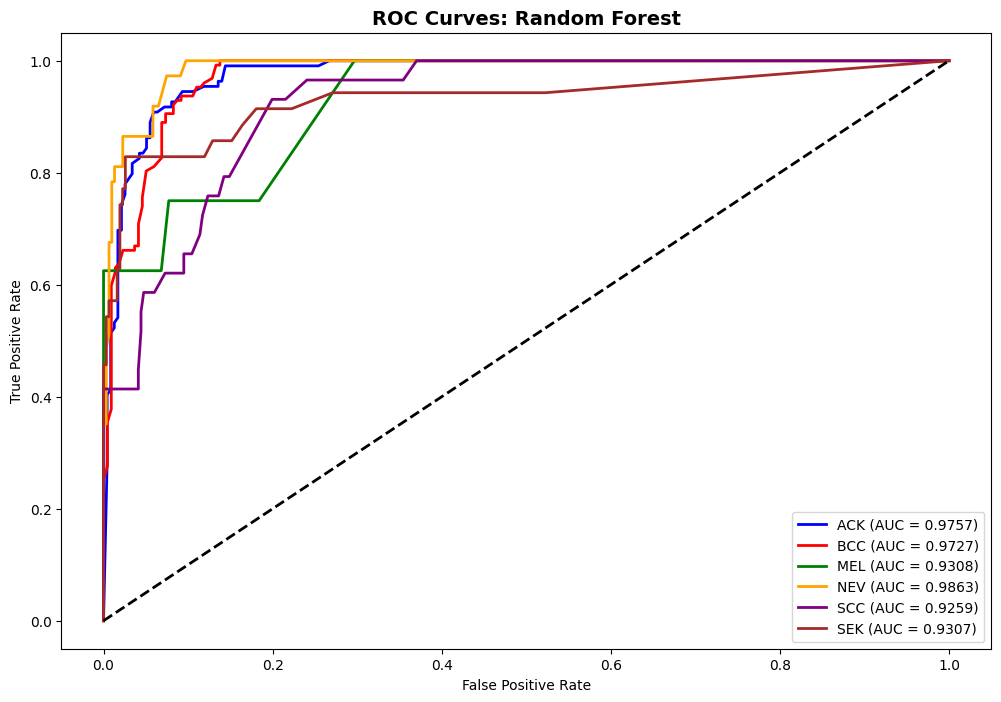

In [62]:
# ROC Curve for multiclass classification using synchronized 345-sample test set
print("\n" + "="*60)
print("ROC CURVE AND AUC SCORE (One-vs-Rest)")
print("="*60 + "\n")

# Binarize the output for the 345-sample test set
y_test_bin = label_binarize(target_test, classes=np.unique(target_test))
n_classes = y_test_bin.shape[1]

fpr = dict(); tpr = dict(); roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(12, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{le_target.classes_[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves: {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

In [63]:
# Macro average AUC
macro_auc = np.mean(list(roc_auc.values()))
print(f"\nMacro-Average AUC: {macro_auc:.4f}")


Macro-Average AUC: 0.9537


## 9. K-FOLD CROSS-VALIDATION RESULTS

In [66]:
# K-Fold evaluation on best model
print("\n" + "="*60)
print("K-FOLD CROSS-VALIDATION RESULTS")
print("="*60 + "\n")

scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(best_model, x_scaled, target,
                            cv=kfold, scoring=scoring_metrics, n_jobs=-1)

print(f"Model: {best_model_name}")
print(f"Number of Folds: 5\n")

for metric in scoring_metrics:
    scores = cv_results[f'test_{metric}']
    print(f"{metric.upper()}:")
    print(f"  Fold Scores: {np.array2string(scores, precision=4, separator=', ')}")
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std():.4f})\n")


K-FOLD CROSS-VALIDATION RESULTS

Model: Random Forest
Number of Folds: 5

ACCURACY:
  Fold Scores: [0.7702, 0.8137, 0.7826, 0.8131, 0.8255]
  Mean: 0.8010 (+/- 0.0210)

PRECISION_MACRO:
  Fold Scores: [0.7397, 0.7442, 0.8063, 0.8713, 0.8304]
  Mean: 0.7984 (+/- 0.0506)

RECALL_MACRO:
  Fold Scores: [0.6185, 0.7151, 0.6742, 0.6921, 0.695 ]
  Mean: 0.6790 (+/- 0.0329)

F1_MACRO:
  Fold Scores: [0.6458, 0.7188, 0.709 , 0.7467, 0.7325]
  Mean: 0.7106 (+/- 0.0348)



## 10. FEATURE IMPORTANCE ANALYSIS


FEATURE IMPORTANCE

            Feature  Importance
                age    0.192377
             region    0.108492
            biopsed    0.081576
          elevation    0.071555
         diameter_2    0.067249
               itch    0.064692
         diameter_1    0.063189
               grew    0.052051
     cancer_history    0.033512
skin_cancer_history    0.033429
              bleed    0.027230
        fitspatrick    0.027077
    has_piped_water    0.026000
              smoke    0.025810
  has_sewage_system    0.025520
             gender    0.024334
            changed    0.024223
          pesticide    0.021754
              drink    0.018064
               hurt    0.011867


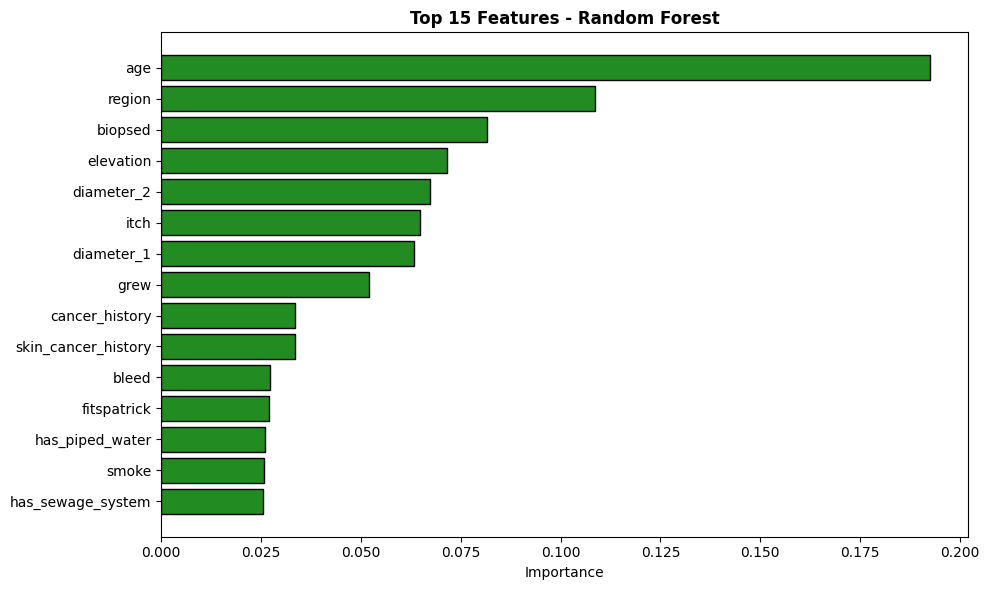

In [67]:
# Feature importance from best model using synchronized feature names (20 features)
if hasattr(best_model, 'feature_importances_'):
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE")
    print("="*60 + "\n")

    feature_importance = best_model.feature_importances_
    # Use x.columns (20 features) instead of X.columns (21 features)
    feature_names = x.columns

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)

    print(importance_df.to_string(index=False))

    plt.figure(figsize=(10, 6))
    top_n = 15
    plt.barh(importance_df['Feature'][:top_n], importance_df['Importance'][:top_n], color='forestgreen', edgecolor='black')
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} Features - {best_model_name}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"\n{best_model_name} does not support direct feature importance extraction.")

## 11. COMPREHENSIVE SUMMARY REPORT

In [68]:
print("\n" + "="*70)
print(" "*15 + "COMPREHENSIVE EVALUATION REPORT")
print("="*70)

# Using the synchronized target_test (345 samples)
print(f"\n📊 DATASET INFORMATION:")
print(f"  • Total samples: {len(meta_clean)}")
print(f"  • Number of features: {x.shape[1]}")
print(f"  • Number of classes: {len(np.unique(target_test))}")
print(f"  • Training samples: {len(target)} ({len(target)/len(meta_clean)*100:.1f}%)")
print(f"  • Test samples: {len(target_test)} ({len(target_test)/len(meta_clean)*100:.1f}%)")

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"  • Test Accuracy: {final_accuracy*100:.2f}%")
print(f"  • Macro Precision: {macro_precision:.4f}")
print(f"  • Macro Recall: {macro_recall:.4f}")
print(f"  • Macro F1-Score: {macro_f1:.4f}")
print(f"  • Macro-Average AUC: {macro_auc:.4f}")

print(f"\n📈 K-FOLD CROSS-VALIDATION (5-Fold):")
print(f"  • Mean Accuracy: {cv_results['test_accuracy'].mean():.4f}")
print(f"  • Mean Precision: {cv_results['test_precision_macro'].mean():.4f}")

print(f"\n🎯 ALL MODELS PERFORMANCE (on 345-sample test set):")
for model_name, acc in sorted(accuracies.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model_name:.<30} {acc*100:>6.2f}%")

print(f"\n" + "="*70)


               COMPREHENSIVE EVALUATION REPORT

📊 DATASET INFORMATION:
  • Total samples: 2298
  • Number of features: 20
  • Number of classes: 6
  • Training samples: 1608 (70.0%)
  • Test samples: 345 (15.0%)

🏆 BEST MODEL: Random Forest
  • Test Accuracy: 84.64%
  • Macro Precision: 0.8526
  • Macro Recall: 0.7435
  • Macro F1-Score: 0.7782
  • Macro-Average AUC: 0.9537

📈 K-FOLD CROSS-VALIDATION (5-Fold):
  • Mean Accuracy: 0.8010
  • Mean Precision: 0.7984

🎯 ALL MODELS PERFORMANCE (on 345-sample test set):
  Random Forest.................  84.64%
  Voting Classifier.............  84.06%
  Gradient Boosting.............  83.19%
  KNN...........................  83.19%
  Extra Trees...................  82.90%
  XGBoost.......................  81.74%
  LightGBM......................  81.16%
  Deep Learning.................  79.13%
  MLP...........................  78.55%
  SVM...........................  76.52%
  Logistic Regression...........  75.94%
  AdaBoost...................

In [69]:
# Create summary metrics table using synchronized variables
print("\n" + "="*70)
print("DETAILED METRICS SUMMARY")
print("="*70 + "\n")

summary_data = {
    'Metric': [
        'Overall Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1-Score',
        'Weighted Precision',
        'Weighted Recall',
        'Weighted F1-Score',
        'Macro-Avg AUC'
    ],
    'Value': [
        f"{final_accuracy:.4f}",
        f"{macro_precision:.4f}",
        f"{macro_recall:.4f}",
        f"{macro_f1:.4f}",
        f"{weighted_precision:.4f}",
        f"{weighted_recall:.4f}",
        f"{weighted_f1:.4f}",
        f"{macro_auc:.4f}"
    ],
    'Percentage': [
        f"{final_accuracy*100:.2f}%",
        f"{macro_precision*100:.2f}%",
        f"{macro_recall*100:.2f}%",
        f"{macro_f1*100:.2f}%",
        f"{weighted_precision*100:.2f}%",
        f"{weighted_recall*100:.2f}%",
        f"{weighted_f1*100:.2f}%",
        f"{macro_auc*100:.2f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("\n" + "="*70)


DETAILED METRICS SUMMARY

            Metric  Value Percentage
  Overall Accuracy 0.8464     84.64%
   Macro Precision 0.8526     85.26%
      Macro Recall 0.7435     74.35%
    Macro F1-Score 0.7782     77.82%
Weighted Precision 0.8518     85.18%
   Weighted Recall 0.8464     84.64%
 Weighted F1-Score 0.8382     83.82%
     Macro-Avg AUC 0.9537     95.37%



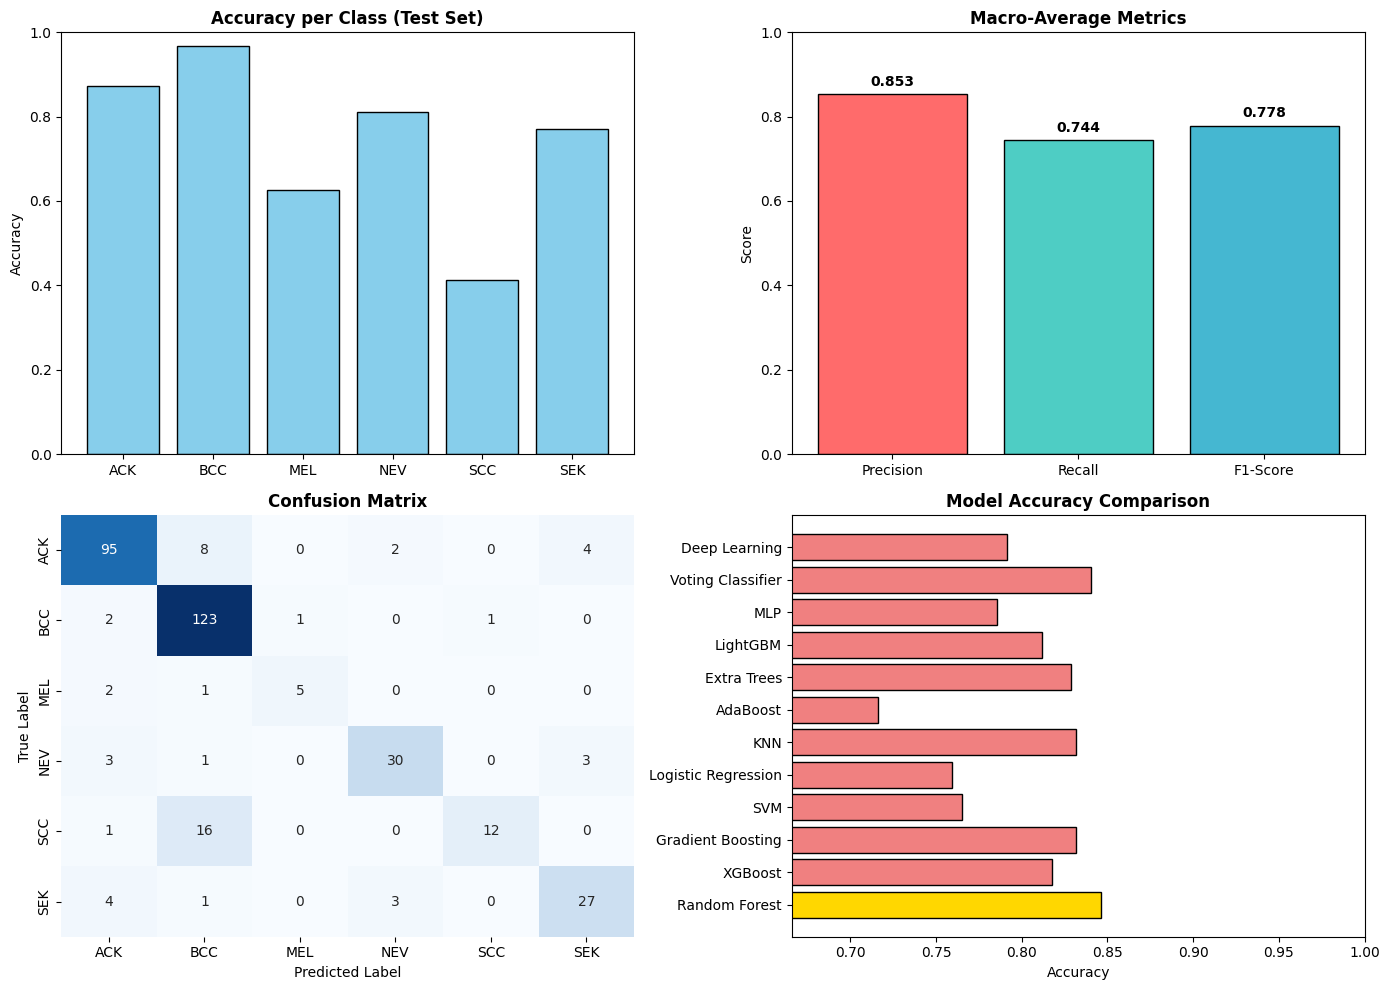


✅ All visualizations and reports are now synchronized!


In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy by class using synchronized target_test
ax1 = axes[0, 0]
class_names = le_target.classes_
accuracy_per_class = []
for i in range(len(class_names)):
    mask = (target_test == i).values
    if mask.sum() > 0:
        class_acc = accuracy_score(target_test[mask], y_pred_best[mask])
        accuracy_per_class.append(class_acc)
    else:
        accuracy_per_class.append(0)

ax1.bar(class_names, accuracy_per_class, color='skyblue', edgecolor='black')
ax1.set_title('Accuracy per Class (Test Set)', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([0, 1])

# Precision, Recall, F1 comparison
ax2 = axes[0, 1]
metrics_comparison = [macro_precision, macro_recall, macro_f1]
metrics_names = ['Precision', 'Recall', 'F1-Score']
ax2.bar(metrics_names, metrics_comparison, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
ax2.set_title('Macro-Average Metrics', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_ylim([0, 1])
for i, v in enumerate(metrics_comparison):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Confusion matrix heatmap
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax3.set_title('Confusion Matrix', fontweight='bold')
ax3.set_ylabel('True Label')
ax3.set_xlabel('Predicted Label')

# Model comparison
ax4 = axes[1, 1]
model_names = list(accuracies.keys())
model_accs = list(accuracies.values())
colors_comp = ['gold' if v == max(model_accs) else 'lightcoral' for v in model_accs]
ax4.barh(model_names, model_accs, color=colors_comp, edgecolor='black')
ax4.set_title('Model Accuracy Comparison', fontweight='bold')
ax4.set_xlabel('Accuracy')
ax4.set_xlim([min(model_accs)-0.05, 1.0])

plt.tight_layout()
plt.show()

print("\n✅ All visualizations and reports are now synchronized!")

## 12. FULL PERFORMANCE COMPARISON ACROSS ALL SPLITS
This section provides a consolidated view of how all models perform on Training, Validation, and Test sets, along with their robust K-Fold Cross-Validation scores.

In [71]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Define the full list of models to evaluate
all_models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Gradient Boosting': gb_model,
    'SVM': svm_model,
    'Logistic Regression': lr_model,
    'KNN': knn_model,
    'AdaBoost': ada_model,
    'Extra Trees': et_model,
    'LightGBM': lgbm_model,
    'MLP': mlp_model,
    'Voting Classifier': voting_clf
}

results_list = []

print("Calculating comprehensive metrics for all models...")

for name, model in all_models.items():
    # K-Fold CV Accuracy (using scaled training data)
    cv_scores = cross_val_score(model, x_scaled, target, cv=kfold, n_jobs=-1)

    # Split Accuracies
    train_acc = accuracy_score(target, model.predict(x_scaled))
    valid_acc = accuracy_score(target_valid, model.predict(x_valid_scaled))
    test_acc = accuracy_score(target_test, model.predict(x_test_scaled))

    results_list.append({
        'Model': name,
        'Train Acc': train_acc,
        'Valid Acc': valid_acc,
        'Test Acc': test_acc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

# Handle Deep Learning Model separately (Keras API differs)
dl_train_acc = dl_model.evaluate(x_scaled, to_categorical(target), verbose=0)[1]
dl_valid_acc = dl_model.evaluate(x_valid_scaled, to_categorical(target_valid), verbose=0)[1]
dl_test_acc = dl_model.evaluate(x_test_scaled, to_categorical(target_test), verbose=0)[1]

# Note: CV for DL models usually requires a KerasClassifier wrapper;
# we'll use the final training accuracy as a proxy or leave as N/A for raw Keras
results_list.append({
    'Model': 'Deep Learning',
    'Train Acc': dl_train_acc,
    'Valid Acc': dl_valid_acc,
    'Test Acc': dl_test_acc,
    'CV Mean': np.nan,
    'CV Std': np.nan
})

# Create and format DataFrame
full_comparison_df = pd.DataFrame(results_list)
full_comparison_df['Average (Splt)'] = full_comparison_df[['Train Acc', 'Valid Acc', 'Test Acc']].mean(axis=1)

# Display nicely formatted table
pd.options.display.float_format = '{:.4f}'.format
display(full_comparison_df.sort_values(by='Test Acc', ascending=False))

Calculating comprehensive metrics for all models...


,Model,Train Acc,Valid Acc,Test Acc,CV Mean,CV Std,Average (Splt)
0,Random Forest,0.9956,0.8145,0.8464,0.8010,0.0210,0.8855
10,Voting Classifier,0.9950,0.8319,0.8406,0.8066,0.0233,0.8892
5,KNN,0.9956,0.7942,0.8319,0.7917,0.0228,0.8739
2,Gradient Boosting,0.9956,0.8058,0.8319,0.7929,0.0245,0.8778
7,Extra Trees,0.9956,0.7826,0.8290,0.7979,0.0240,0.8691
1,XGBoost,0.9894,0.8087,0.8174,0.8041,0.0247,0.8718
8,LightGBM,0.9956,0.7971,0.8116,0.7967,0.0246,0.8681
11,Deep Learning,0.8638,0.7826,0.7913,NaN,NaN,0.8126
9,MLP,0.9639,0.7681,0.7855,0.7699,0.0281,0.8392
3,SVM,0.7767,0.7217,0.7652,0.7444,0.0311,0.7546


# ADVANCED EVALUATION: SECTIONS 13-20

The sections below extend the analysis above: statistical significance testing, explainability (SHAP/permutation importance), probability calibration, confidence intervals, a bias check across feature-importance methods, computational cost, error analysis, and class-imbalance handling.

In [72]:
# Install additional packages required for Sections 13-20
import subprocess
import sys

extra_packages = ['scikit-posthocs', 'shap', 'imbalanced-learn', 'psutil']

print("Installing additional packages for advanced analysis...\n")
for package in extra_packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} installed successfully")
    except subprocess.CalledProcessError:
        print(f"✗ Failed to install {package}")

print("\n✅ Additional packages ready!")


Installing additional packages for advanced analysis...

✓ scikit-posthocs installed successfully
✓ shap installed successfully
✓ imbalanced-learn installed successfully
✓ psutil installed successfully

✅ Additional packages ready!


In [73]:
# Imports for Sections 13-20
import time
import psutil
import shap
import scikit_posthocs as sp
from scipy import stats
from scipy.stats import wilcoxon, friedmanchisquare, spearmanr
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

print("Additional libraries imported for Sections 13-20!")


Additional libraries imported for Sections 13-20!


## 13. STATISTICAL SIGNIFICANCE TESTING
**Requirement addressed: #1 - Statistical Significance Testing (McNemar, Wilcoxon Signed-Rank, Friedman, Nemenyi)**

We test whether the accuracy differences between models are statistically significant rather than due to random split/fold variation:
- **Friedman test** - omnibus test across all models' 5-fold CV accuracy scores.
- **Nemenyi post-hoc test** - pairwise comparison following a significant Friedman result.
- **Wilcoxon signed-rank test** - paired comparison of the best model against each other model across the same CV folds.
- **McNemar's test** - paired comparison of the best model against each other model on the *same* test-set predictions (contingency table of correct/incorrect).

In [74]:
# --- Friedman test across all classical models (5-fold CV accuracy) ---
print("Computing 5-fold CV score matrix for all classical models...\n")

cv_score_matrix = {}
for name, model in models.items():
    scores = cross_val_score(model, x_scaled, target, cv=kfold, n_jobs=-1)
    cv_score_matrix[name] = scores

cv_scores_df = pd.DataFrame(cv_score_matrix)
print("Per-fold CV accuracy (rows = folds, columns = models):")
print(cv_scores_df.round(4))

friedman_stat, friedman_p = friedmanchisquare(*[cv_scores_df[c].values for c in cv_scores_df.columns])
print(f"\nFriedman test: chi-square = {friedman_stat:.4f}, p-value = {friedman_p:.4g}")
if friedman_p < 0.05:
    print("=> Significant differences exist among the models' CV accuracy distributions (p < 0.05).")
else:
    print("=> No statistically significant differences detected among the models (p >= 0.05).")


Computing 5-fold CV score matrix for all classical models...

Per-fold CV accuracy (rows = folds, columns = models):
   Random Forest  XGBoost  Gradient Boosting    SVM  Logistic Regression  \
0         0.7702   0.7609             0.7516 0.7360               0.7329   
1         0.8137   0.8137             0.8075 0.7671               0.7764   
2         0.7826   0.7950             0.7795 0.6894               0.7112   
3         0.8131   0.8193             0.8069 0.7508               0.7445   
4         0.8255   0.8318             0.8193 0.7788               0.7819   

     KNN  AdaBoost  Extra Trees  LightGBM    MLP  Voting Classifier  
0 0.7671    0.7081       0.7733    0.7547 0.7267             0.7764  
1 0.8106    0.7329       0.8043    0.8168 0.7795             0.8261  
2 0.7609    0.6460       0.7733    0.7826 0.7484             0.7826  
3 0.8069    0.6916       0.8006    0.8131 0.7975             0.8131  
4 0.8131    0.7103       0.8380    0.8162 0.7975             0.8349  

Fried

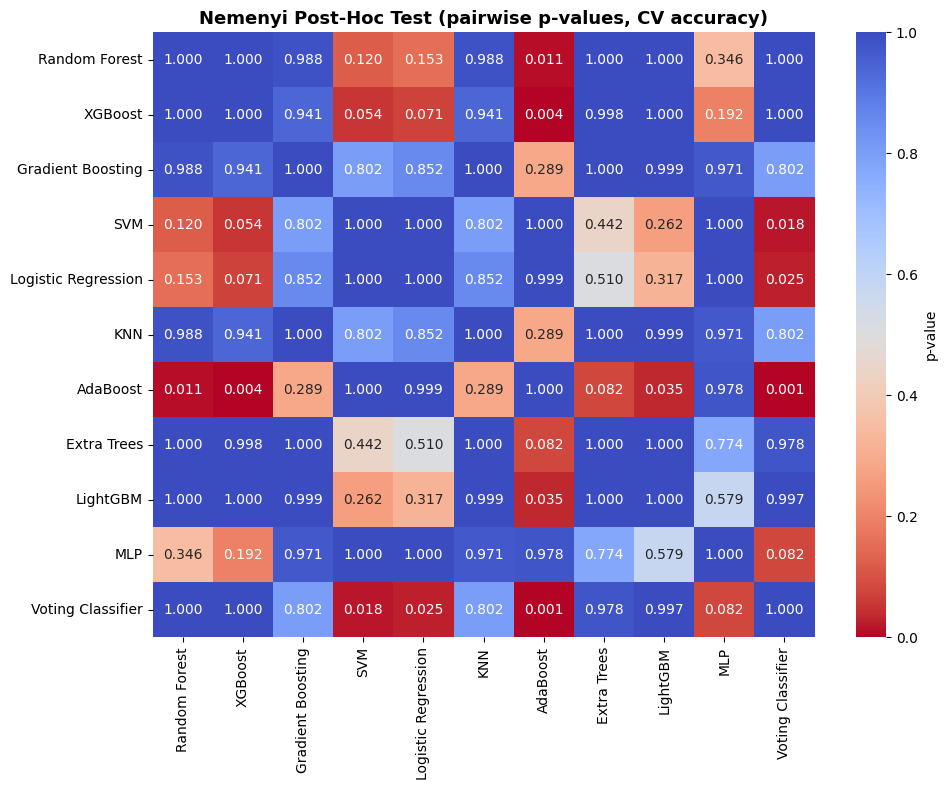

Pairs with p < 0.05 (statistically significant difference):
  Random Forest  vs  AdaBoost:  p = 0.0110
  XGBoost  vs  AdaBoost:  p = 0.0037
  SVM  vs  Voting Classifier:  p = 0.0182
  Logistic Regression  vs  Voting Classifier:  p = 0.0252
  AdaBoost  vs  LightGBM:  p = 0.0345
  AdaBoost  vs  Voting Classifier:  p = 0.0009


In [75]:
# --- Nemenyi post-hoc test (pairwise, after Friedman) ---
nemenyi_pvals = sp.posthoc_nemenyi_friedman(cv_scores_df.values)
nemenyi_pvals.columns = cv_scores_df.columns
nemenyi_pvals.index = cv_scores_df.columns

plt.figure(figsize=(10, 8))
sns.heatmap(nemenyi_pvals, annot=True, fmt='.3f', cmap='coolwarm_r', vmin=0, vmax=1, cbar_kws={'label': 'p-value'})
plt.title('Nemenyi Post-Hoc Test (pairwise p-values, CV accuracy)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Pairs with p < 0.05 (statistically significant difference):")
sig_pairs = []
for i, m1 in enumerate(nemenyi_pvals.columns):
    for j, m2 in enumerate(nemenyi_pvals.columns):
        if i < j and nemenyi_pvals.iloc[i, j] < 0.05:
            sig_pairs.append((m1, m2, nemenyi_pvals.iloc[i, j]))
for m1, m2, p in sig_pairs:
    print(f"  {m1}  vs  {m2}:  p = {p:.4f}")
if not sig_pairs:
    print("  None -- no pair reaches p < 0.05 after the Nemenyi correction.")


In [76]:
# --- Wilcoxon signed-rank test: best model vs every other model (paired CV folds) ---
print(f"Wilcoxon signed-rank test -- {best_model_name} vs every other model (paired CV folds):\n")

wilcoxon_results = []
for name in cv_scores_df.columns:
    if name == best_model_name:
        continue
    try:
        stat, p = wilcoxon(cv_scores_df[best_model_name], cv_scores_df[name])
    except ValueError:
        stat, p = np.nan, 1.0  # identical scores across all folds
    wilcoxon_results.append({'Comparison': f'{best_model_name} vs {name}', 'W-statistic': stat,
                              'p-value': p, 'Significant (p<0.05)': p < 0.05})
    print(f"  {best_model_name} vs {name:.<25} W={stat}, p={p:.4g}")

wilcoxon_df = pd.DataFrame(wilcoxon_results)
print("\n", wilcoxon_df.to_string(index=False))


Wilcoxon signed-rank test -- Random Forest vs every other model (paired CV folds):

  Random Forest vs XGBoost.................. W=3.0, p=0.625
  Random Forest vs Gradient Boosting........ W=0.0, p=0.0625
  Random Forest vs SVM...................... W=0.0, p=0.0625
  Random Forest vs Logistic Regression...... W=0.0, p=0.0625
  Random Forest vs KNN...................... W=0.0, p=0.0625
  Random Forest vs AdaBoost................. W=0.0, p=0.0625
  Random Forest vs Extra Trees.............. W=5.5, p=0.6875
  Random Forest vs LightGBM................. W=1.0, p=0.5
  Random Forest vs MLP...................... W=0.0, p=0.0625
  Random Forest vs Voting Classifier........ W=0.0, p=0.25

                           Comparison  W-statistic  p-value  Significant (p<0.05)
            Random Forest vs XGBoost       3.0000   0.6250                 False
  Random Forest vs Gradient Boosting       0.0000   0.0625                 False
                Random Forest vs SVM       0.0000   0.0625         

In [77]:
# --- McNemar's test: best model vs every other model (paired test-set predictions) ---
print(f"McNemar's test -- {best_model_name} vs every other model (paired test-set errors):\n")

y_true_arr = np.asarray(target_test)
best_correct = (y_pred_best == y_true_arr)

mcnemar_results = []
for name, pred in y_preds.items():
    if name == best_model_name:
        continue
    other_correct = (pred == y_true_arr)
    both_correct = np.sum(best_correct & other_correct)
    only_best = np.sum(best_correct & ~other_correct)
    only_other = np.sum(~best_correct & other_correct)
    neither = np.sum(~best_correct & ~other_correct)
    table = [[both_correct, only_best], [only_other, neither]]
    result = mcnemar(table, exact=(only_best + only_other) < 25, correction=True)
    mcnemar_results.append({'Comparison': f'{best_model_name} vs {name}', 'statistic': result.statistic,
                             'p-value': result.pvalue, 'Significant (p<0.05)': result.pvalue < 0.05})
    print(f"  {best_model_name} vs {name:.<25} statistic={result.statistic:.4f}, p={result.pvalue:.4g}")

mcnemar_df = pd.DataFrame(mcnemar_results)
print("\n", mcnemar_df.to_string(index=False))


McNemar's test -- Random Forest vs every other model (paired test-set errors):

  Random Forest vs XGBoost.................. statistic=3.0000, p=0.02127
  Random Forest vs Gradient Boosting........ statistic=8.0000, p=0.3833
  Random Forest vs SVM...................... statistic=15.8478, p=6.865e-05
  Random Forest vs Logistic Regression...... statistic=16.8200, p=4.11e-05
  Random Forest vs KNN...................... statistic=9.0000, p=0.4049
  Random Forest vs AdaBoost................. statistic=29.7846, p=4.828e-08
  Random Forest vs Extra Trees.............. statistic=0.9615, p=0.3268
  Random Forest vs LightGBM................. statistic=6.0000, p=0.02266
  Random Forest vs MLP...................... statistic=9.3023, p=0.002289
  Random Forest vs Voting Classifier........ statistic=5.0000, p=0.7744
  Random Forest vs Deep Learning............ statistic=7.9024, p=0.004937

                           Comparison  statistic  p-value  Significant (p<0.05)
            Random Forest vs X

## 14. SHAP AND PERMUTATION IMPORTANCE
**Requirement addressed: #2 - SHAP / Permutation Importance**

We compute two model-agnostic (or near model-agnostic) explanations for the best model:
- **SHAP values** - how much each feature pushes predictions away from the average, per class.
- **Permutation importance** - the drop in test-set accuracy when a single feature's values are randomly shuffled.

Computing SHAP values for the best model: Random Forest (RandomForestClassifier)

            Feature  Mean |SHAP value|
            biopsed             0.0526
          elevation             0.0345
               itch             0.0331
                age             0.0327
               grew             0.0284
             region             0.0250
              bleed             0.0188
         diameter_2             0.0121
            changed             0.0121
skin_cancer_history             0.0108
     cancer_history             0.0106
         diameter_1             0.0094
              smoke             0.0082
    has_piped_water             0.0081
  has_sewage_system             0.0074
             gender             0.0056
          pesticide             0.0056
               hurt             0.0052
              drink             0.0042
        fitspatrick             0.0037


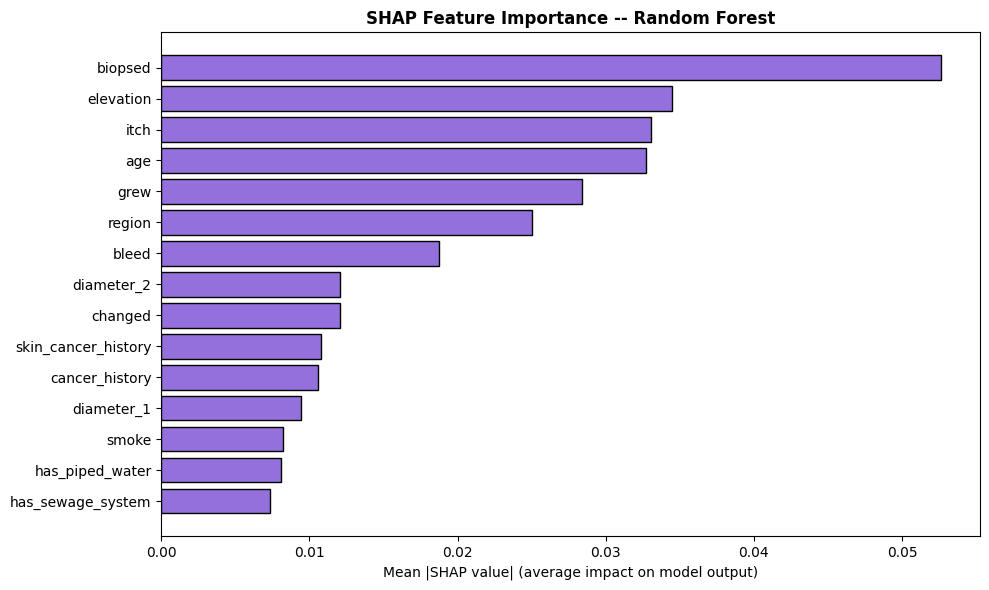

In [78]:
# --- SHAP values for the best model ---
print(f"Computing SHAP values for the best model: {best_model_name} ({type(best_model).__name__})\n")

feature_names = list(x.columns)
TREE_BASED = ('RandomForestClassifier', 'XGBClassifier', 'GradientBoostingClassifier',
              'ExtraTreesClassifier', 'LGBMClassifier')

if type(best_model).__name__ in TREE_BASED:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(x_test_scaled)
    shap_arr = np.array(shap_values)
else:
    print("Best model is not a native tree ensemble -- using a slower model-agnostic SHAP explainer")
    print("on a 100-sample subset of the test set for tractability.\n")
    background = shap.sample(x_scaled, 50, random_state=seed)
    sample_idx = np.random.RandomState(seed).choice(len(x_test_scaled), size=min(100, len(x_test_scaled)), replace=False)
    explainer = shap.Explainer(best_model.predict_proba, background)
    shap_values_obj = explainer(x_test_scaled[sample_idx])
    shap_arr = shap_values_obj.values

# shap_arr can be (n_samples, n_features) or (n_samples, n_features, n_classes) depending on model/shap version
feat_axis = [i for i, s in enumerate(shap_arr.shape) if s == len(feature_names)][0]
other_axes = tuple(i for i in range(shap_arr.ndim) if i != feat_axis)
shap_importance = np.abs(shap_arr).mean(axis=other_axes)

shap_df = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP value|': shap_importance}).sort_values('Mean |SHAP value|', ascending=False)
print(shap_df.to_string(index=False))

plt.figure(figsize=(10, 6))
top_shap = shap_df.head(15).iloc[::-1]
plt.barh(top_shap['Feature'], top_shap['Mean |SHAP value|'], color='mediumpurple', edgecolor='black')
plt.xlabel('Mean |SHAP value| (average impact on model output)')
plt.title(f'SHAP Feature Importance -- {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.show()


Computing permutation importance on the held-out test set...

            Feature  Permutation Importance    Std
            biopsed                  0.1764 0.0144
                age                  0.0938 0.0114
          elevation                  0.0899 0.0145
               itch                  0.0635 0.0091
               grew                  0.0577 0.0106
             region                  0.0501 0.0120
              bleed                  0.0461 0.0074
            changed                  0.0146 0.0058
               hurt                  0.0084 0.0054
         diameter_1                  0.0068 0.0060
        fitspatrick                  0.0046 0.0023
          pesticide                  0.0033 0.0041
         diameter_2                  0.0033 0.0061
skin_cancer_history                 -0.0016 0.0027
     cancer_history                 -0.0020 0.0049
              smoke                 -0.0030 0.0019
  has_sewage_system                 -0.0043 0.0038
             gender 

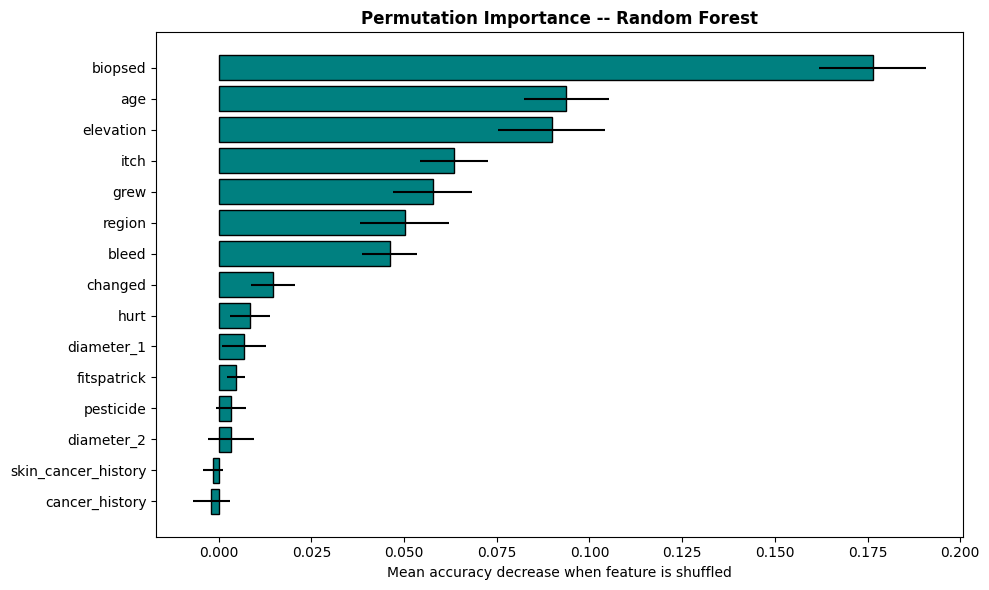

In [79]:
# --- Permutation importance for the best model (test set) ---
print("Computing permutation importance on the held-out test set...\n")

perm_result = permutation_importance(best_model, x_test_scaled, target_test, n_repeats=20, random_state=seed, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Permutation Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Permutation Importance', ascending=False)
print(perm_df.to_string(index=False))

plt.figure(figsize=(10, 6))
top_perm = perm_df.head(15).iloc[::-1]
plt.barh(top_perm['Feature'], top_perm['Permutation Importance'], xerr=top_perm['Std'], color='teal', edgecolor='black')
plt.xlabel('Mean accuracy decrease when feature is shuffled')
plt.title(f'Permutation Importance -- {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.show()


## 15. CALIBRATION ANALYSIS
**Requirement addressed: #3 - Calibration Analysis (Calibration Curve, Reliability Diagram, Brier Score)**

A model can be accurate yet poorly calibrated (its predicted probabilities don't match true likelihoods). We check this per class using a One-vs-Rest reliability diagram and the Brier score (lower is better, 0 = perfect).

Computing per-class calibration for the best model: Random Forest



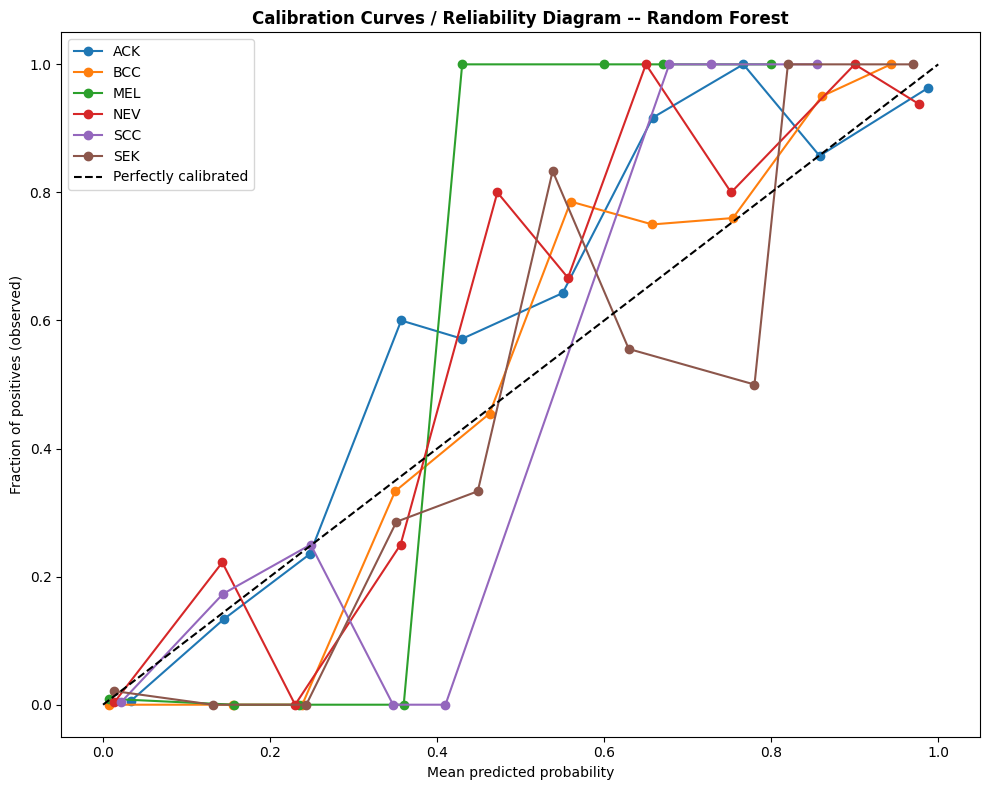

Class  Brier Score
  MEL       0.0121
  NEV       0.0298
  SEK       0.0366
  SCC       0.0468
  ACK       0.0614
  BCC       0.0667

Mean multiclass Brier score: 0.0422  (0 = perfect, 1 = worst)


In [80]:
# --- Calibration curves (reliability diagram) and Brier scores, One-vs-Rest ---
print(f"Computing per-class calibration for the best model: {best_model_name}\n")

y_test_bin_cal = label_binarize(target_test, classes=np.unique(target_test))
n_classes_cal = y_test_bin_cal.shape[1]

plt.figure(figsize=(10, 8))
brier_scores = {}
for i in range(n_classes_cal):
    frac_pos, mean_pred = calibration_curve(y_test_bin_cal[:, i], y_pred_proba[:, i], n_bins=10, strategy='uniform')
    plt.plot(mean_pred, frac_pos, marker='o', label=f'{le_target.classes_[i]}')
    brier_scores[le_target.classes_[i]] = brier_score_loss(y_test_bin_cal[:, i], y_pred_proba[:, i])

plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives (observed)')
plt.title(f'Calibration Curves / Reliability Diagram -- {best_model_name}', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

brier_df = pd.DataFrame({'Class': list(brier_scores.keys()), 'Brier Score': list(brier_scores.values())}).sort_values('Brier Score')
print(brier_df.to_string(index=False))
print(f"\nMean multiclass Brier score: {np.mean(list(brier_scores.values())):.4f}  (0 = perfect, 1 = worst)")


## 16. CONFIDENCE INTERVALS
**Requirement addressed: #4 - Confidence Intervals (Bootstrap or Cross-Validation Confidence Intervals)**

Point estimates (e.g., "84.64% accuracy") hide the uncertainty coming from a finite test set. We report two complementary intervals: a **bootstrap 95% CI** (resampling the test-set predictions) and a **CV-based 95% CI** (t-distribution over the 5 fold scores).

In [81]:
# --- Bootstrap confidence intervals (test set) ---
print(f"Bootstrap 95% confidence intervals for {best_model_name} (test set, 1000 resamples)...\n")

rng = np.random.RandomState(seed)
n_boot = 1000
y_true_ci = np.asarray(target_test)
n_test = len(y_true_ci)

boot_metrics = {'Accuracy': [], 'Macro Precision': [], 'Macro Recall': [], 'Macro F1': []}
for _ in range(n_boot):
    idx = rng.randint(0, n_test, n_test)
    yt, yp = y_true_ci[idx], y_pred_best[idx]
    boot_metrics['Accuracy'].append(accuracy_score(yt, yp))
    boot_metrics['Macro Precision'].append(precision_score(yt, yp, average='macro', zero_division=0))
    boot_metrics['Macro Recall'].append(recall_score(yt, yp, average='macro', zero_division=0))
    boot_metrics['Macro F1'].append(f1_score(yt, yp, average='macro', zero_division=0))

ci_rows = []
for metric_name, values in boot_metrics.items():
    lo, hi = np.percentile(values, [2.5, 97.5])
    ci_rows.append({'Metric': metric_name, 'Point Estimate': np.mean(values), '95% CI Lower': lo, '95% CI Upper': hi})

bootstrap_ci_df = pd.DataFrame(ci_rows)
print("Bootstrap confidence intervals:")
print(bootstrap_ci_df.round(4).to_string(index=False))

# --- CV-based confidence interval (t-distribution over the 5 fold scores) ---
cv_best_scores = cv_scores_df[best_model_name].values
cv_mean = cv_best_scores.mean()
cv_sem = stats.sem(cv_best_scores)
cv_lo, cv_hi = stats.t.interval(0.95, len(cv_best_scores) - 1, loc=cv_mean, scale=cv_sem)
print(f"\nCV-based 95% CI for {best_model_name} accuracy: {cv_mean:.4f}  [{cv_lo:.4f}, {cv_hi:.4f}]")
print(f"(from 5-fold scores: {np.round(cv_best_scores, 4)})")


Bootstrap 95% confidence intervals for Random Forest (test set, 1000 resamples)...

Bootstrap confidence intervals:
         Metric  Point Estimate  95% CI Lower  95% CI Upper
       Accuracy          0.8458        0.8029        0.8870
Macro Precision          0.8531        0.7788        0.9103
   Macro Recall          0.7443        0.6621        0.8218
       Macro F1          0.7742        0.6962        0.8397

CV-based 95% CI for Random Forest accuracy: 0.8010  [0.7719, 0.8301]
(from 5-fold scores: [0.7702 0.8137 0.7826 0.8131 0.8255])


## 17. FEATURE IMPORTANCE BIAS VALIDATION
**Requirement addressed: #5 - Feature Importance Bias Validation (Compare MDI vs SHAP vs Permutation Importance)**

Mean Decrease in Impurity (MDI, i.e. `feature_importances_`) is known to be biased toward high-cardinality / continuous features. We cross-check it against SHAP and permutation importance (both computed in Section 14) using Spearman rank correlation -- strong agreement supports the MDI ranking; disagreement is evidence of MDI bias and should be reported as such.

In [82]:
# --- Compare MDI vs Permutation vs SHAP rankings ---
print("Comparing MDI (built-in), Permutation, and SHAP feature importance rankings...\n")

def normalize(v):
    v = np.asarray(v, dtype=float)
    v = np.clip(v, 0, None)
    return v / v.sum() if v.sum() != 0 else v

comparison_data = {'Feature': feature_names}
if hasattr(best_model, 'feature_importances_'):
    comparison_data['MDI'] = normalize(best_model.feature_importances_)
else:
    print(f"{best_model_name} has no native feature_importances_ (not a single tree ensemble) -- MDI column omitted.\n")

comparison_data['Permutation'] = normalize(perm_df.set_index('Feature').loc[feature_names, 'Permutation Importance'].values)
comparison_data['SHAP'] = normalize(shap_df.set_index('Feature').loc[feature_names, 'Mean |SHAP value|'].values)

bias_df = pd.DataFrame(comparison_data)
value_cols = [c for c in bias_df.columns if c != 'Feature']
for c in value_cols:
    bias_df[f'{c}_rank'] = bias_df[c].rank(ascending=False).astype(int)

print(bias_df.sort_values(value_cols[0], ascending=False).to_string(index=False))

print("\nSpearman rank correlation between importance methods:")
for i in range(len(value_cols)):
    for j in range(i + 1, len(value_cols)):
        corr = spearmanr(bias_df[value_cols[i]], bias_df[value_cols[j]]).correlation
        print(f"  {value_cols[i]} vs {value_cols[j]}: rho = {corr:.4f}")


Comparing MDI (built-in), Permutation, and SHAP feature importance rankings...

            Feature    MDI  Permutation   SHAP  MDI_rank  Permutation_rank  SHAP_rank
                age 0.1924       0.1516 0.0997         1                 2          4
             region 0.1085       0.0811 0.0762         2                 6          6
            biopsed 0.0816       0.2851 0.1604         3                 1          1
          elevation 0.0716       0.1453 0.1051         4                 3          2
         diameter_2 0.0672       0.0054 0.0369         5                13          8
               itch 0.0647       0.1026 0.1008         6                 4          3
         diameter_1 0.0632       0.0110 0.0287         7                10         12
               grew 0.0521       0.0933 0.0866         8                 5          5
     cancer_history 0.0335       0.0000 0.0322         9                17         11
skin_cancer_history 0.0334       0.0000 0.0329        10    

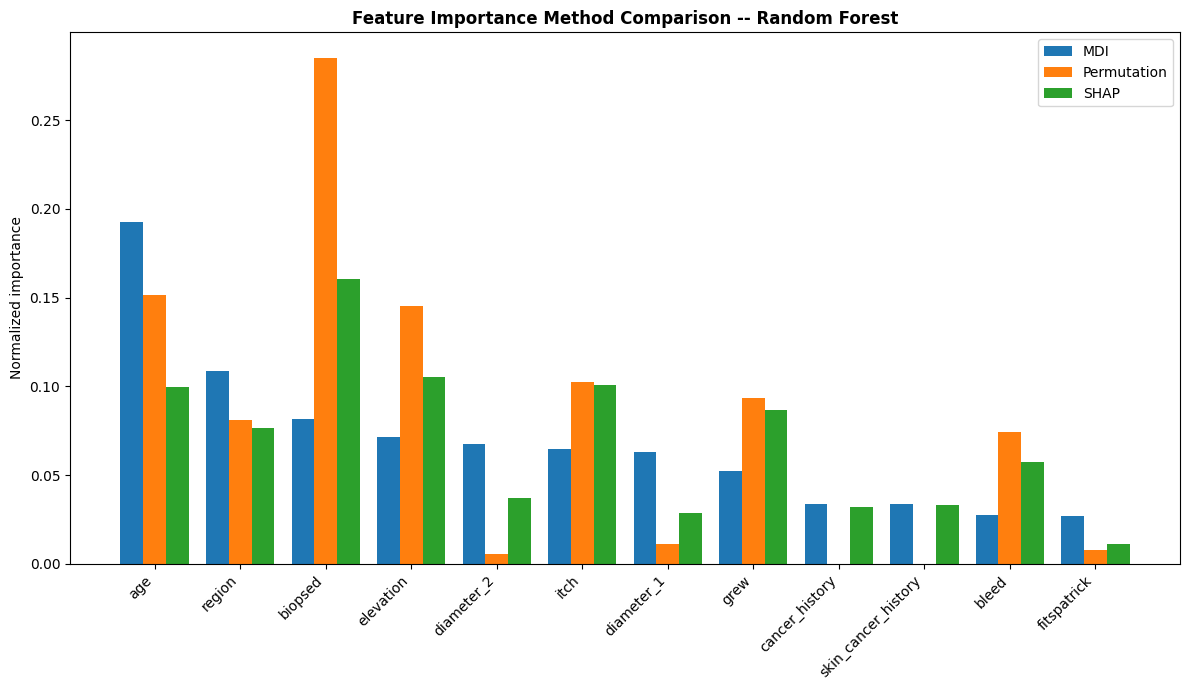

In [83]:
# --- Visual comparison of the top features across methods ---
plt.figure(figsize=(12, 7))
top_n = 12
value_cols = [c for c in bias_df.columns if c not in ('Feature',) and not c.endswith('_rank')]
plot_df = bias_df.sort_values(value_cols[0], ascending=False).head(top_n)
x_pos = np.arange(top_n)
width = 0.8 / len(value_cols)
for k, c in enumerate(value_cols):
    plt.bar(x_pos + k * width, plot_df[c], width=width, label=c)
plt.xticks(x_pos + width * (len(value_cols) - 1) / 2, plot_df['Feature'], rotation=45, ha='right')
plt.ylabel('Normalized importance')
plt.title(f'Feature Importance Method Comparison -- {best_model_name}', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


## 18. COMPUTATIONAL PERFORMANCE COMPARISON
**Requirement addressed: #6 - Computational Performance Comparison (training time, inference time, RAM, CPU/GPU usage)**

Accuracy alone doesn't tell you what a model costs to deploy. We time a fresh fit/predict cycle for every classical model (same hyperparameters as tuned earlier) and track the training-time RAM increase of the Python process. The Deep Learning (Keras) model is timed separately for inference only, since it was already trained with a validation split earlier in the notebook.

In [84]:
# --- Training time, inference time, and memory footprint per model ---
import os as _os

print("Measuring training time, inference time, and memory footprint for each classical model...\n")
print(f"CPU cores available: {psutil.cpu_count(logical=False)} physical / {psutil.cpu_count(logical=True)} logical\n")

process = psutil.Process(_os.getpid())
perf_rows = []
for name, model in models.items():
    fresh_model = clone(model)

    mem_before = process.memory_info().rss / (1024 ** 2)
    t0 = time.perf_counter()
    fresh_model.fit(x_scaled, target)
    train_time = time.perf_counter() - t0
    mem_after_train = process.memory_info().rss / (1024 ** 2)

    t0 = time.perf_counter()
    _ = fresh_model.predict(x_test_scaled)
    infer_time = time.perf_counter() - t0

    perf_rows.append({
        'Model': name,
        'Train Time (s)': round(train_time, 4),
        'Inference Time (s)': round(infer_time, 5),
        'Inference (ms/sample)': round(infer_time / len(x_test_scaled) * 1000, 5),
        'Process RSS Increase (MB)': round(mem_after_train - mem_before, 2),
    })

# Deep Learning inference timing (Keras model; training already done earlier with epochs/validation)
t0 = time.perf_counter()
_ = dl_model.predict(x_test_scaled, verbose=0)
dl_infer_time = time.perf_counter() - t0
perf_rows.append({
    'Model': 'Deep Learning',
    'Train Time (s)': np.nan,
    'Inference Time (s)': round(dl_infer_time, 5),
    'Inference (ms/sample)': round(dl_infer_time / len(x_test_scaled) * 1000, 5),
    'Process RSS Increase (MB)': np.nan,
})

perf_df = pd.DataFrame(perf_rows).sort_values('Train Time (s)')
print(perf_df.to_string(index=False))


Measuring training time, inference time, and memory footprint for each classical model...

CPU cores available: 1 physical / 2 logical

              Model  Train Time (s)  Inference Time (s)  Inference (ms/sample)  Process RSS Increase (MB)
                KNN          0.0008              0.0139                 0.0402                     0.0000
Logistic Regression          0.0426              0.0003                 0.0008                     0.0000
           AdaBoost          0.1184              0.0102                 0.0296                     0.0000
           LightGBM          0.3688              0.0144                 0.0418                     1.6900
                SVM          0.3902              0.0191                 0.0553                     0.0000
      Random Forest          0.4198              0.0336                 0.0973                     6.7000
        Extra Trees          0.4879              0.0655                 0.1898                    37.8200
            XGBo

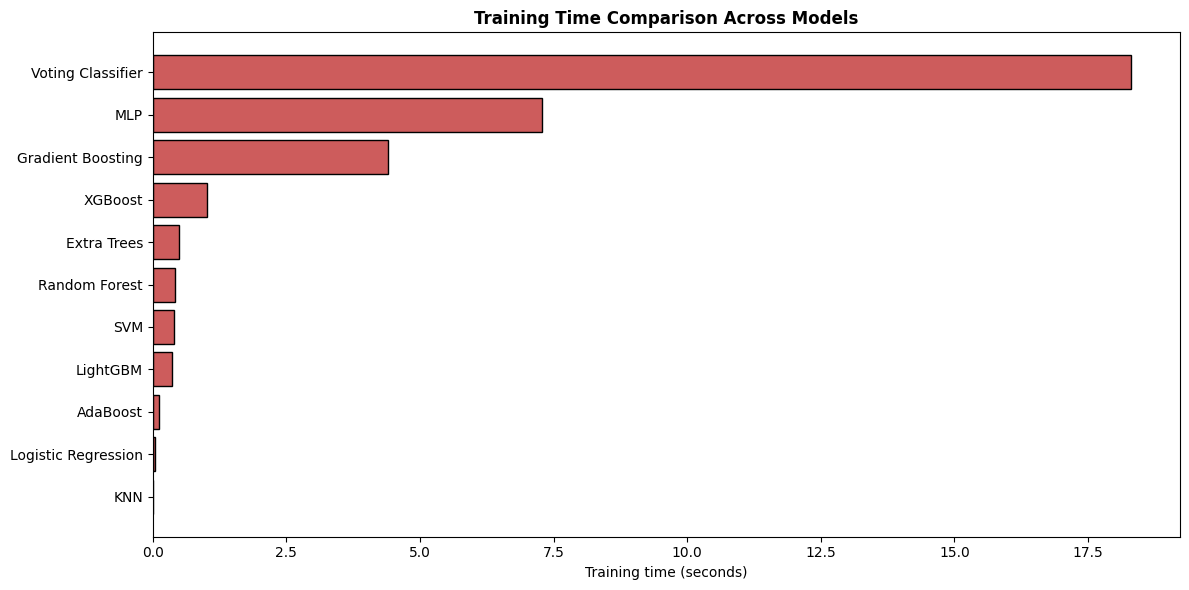

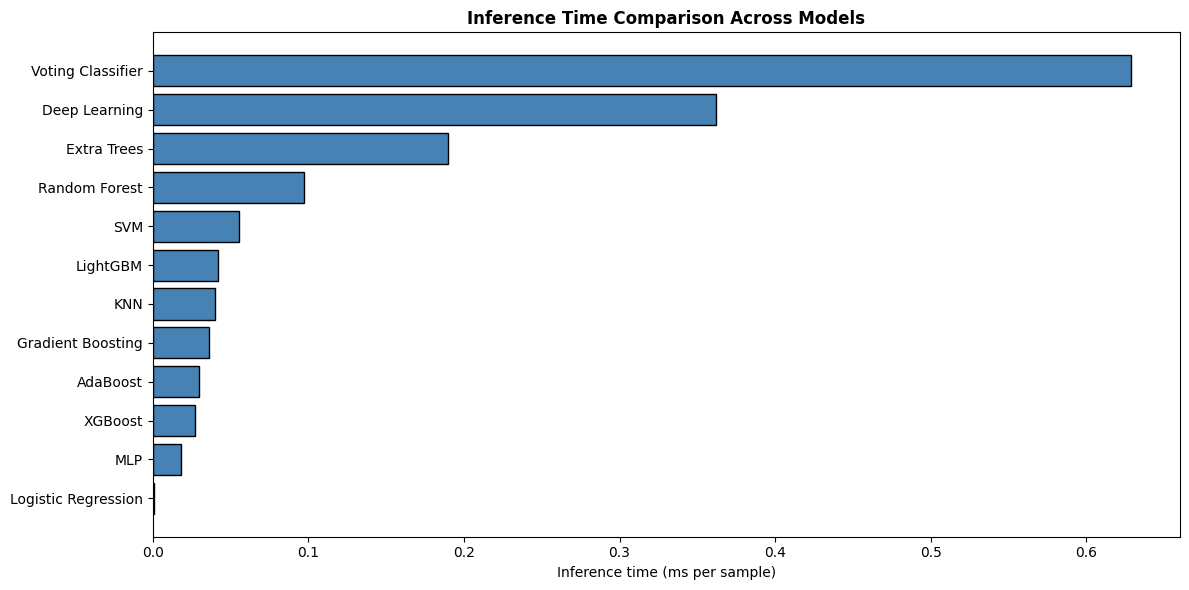

In [85]:
# --- Visualize training time comparison ---
plt.figure(figsize=(12, 6))
plot_perf = perf_df.dropna(subset=['Train Time (s)']).sort_values('Train Time (s)')
plt.barh(plot_perf['Model'], plot_perf['Train Time (s)'], color='indianred', edgecolor='black')
plt.xlabel('Training time (seconds)')
plt.title('Training Time Comparison Across Models', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plot_infer = perf_df.sort_values('Inference (ms/sample)')
plt.barh(plot_infer['Model'], plot_infer['Inference (ms/sample)'], color='steelblue', edgecolor='black')
plt.xlabel('Inference time (ms per sample)')
plt.title('Inference Time Comparison Across Models', fontweight='bold')
plt.tight_layout()
plt.show()


## 19. ERROR ANALYSIS
**Requirement addressed: #7 - Error Analysis (Extract misclassified samples and analyze confusion cases)**

We extract every misclassified test-set sample for the best model, identify the dominant confusion pairs, and compare the average feature values of misclassified vs. correctly classified samples to look for systematic patterns behind the errors.

In [86]:
# --- Extract misclassified samples and confusion pairs ---
print(f"Extracting misclassified samples for the best model: {best_model_name}\n")

y_true_err = np.asarray(target_test)
mis_mask = y_true_err != y_pred_best

error_df = x_test.copy()
error_df['True_Label'] = le_target.inverse_transform(y_true_err)
error_df['Predicted_Label'] = le_target.inverse_transform(y_pred_best)

misclassified_df = error_df[mis_mask].copy()
correct_df = error_df[~mis_mask].copy()

print(f"Total misclassified: {mis_mask.sum()} / {len(y_true_err)}  ({mis_mask.mean() * 100:.2f}% error rate)\n")

print("Top confusion pairs (True -> Predicted):")
confusion_pairs = misclassified_df.groupby(['True_Label', 'Predicted_Label']).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

print("\nSample of misclassified cases:")
print(misclassified_df.head(10).to_string())


Extracting misclassified samples for the best model: Random Forest

Total misclassified: 53 / 345  (15.36% error rate)

Top confusion pairs (True -> Predicted):
True_Label  Predicted_Label
SCC         BCC                16
ACK         BCC                 8
SEK         ACK                 4
ACK         SEK                 4
NEV         SEK                 3
            ACK                 3
SEK         NEV                 3
ACK         NEV                 2
BCC         ACK                 2
MEL         ACK                 2
dtype: int64

Sample of misclassified cases:
      smoke  drink  age  pesticide  gender  skin_cancer_history  cancer_history  has_piped_water  has_sewage_system  fitspatrick  region  diameter_1  diameter_2  itch  grew  hurt  changed  bleed  elevation  biopsed True_Label Predicted_Label
2289      1      0   66          0       1                    1               0                1                  1       2.0000       4     20.0000     15.0000     1     0     1      

                     Misclassified (mean)  Correctly Classified (mean)  Difference
diameter_2                         4.7360                       5.1880     -0.4530
diameter_1                         6.4340                       6.8770     -0.4430
region                             5.7360                       5.3660      0.3690
bleed                              0.0940                       0.3150     -0.2210
changed                            0.6230                       0.4420      0.1810
age                               60.0190                      60.1640     -0.1460
grew                               0.8490                       0.7260      0.1230
itch                               0.5280                       0.6470     -0.1190
skin_cancer_history                0.9250                       1.0410     -0.1170
drink                              0.7550                       0.8660     -0.1120
biopsed                            0.6600                       0.5720      0.0880
gend

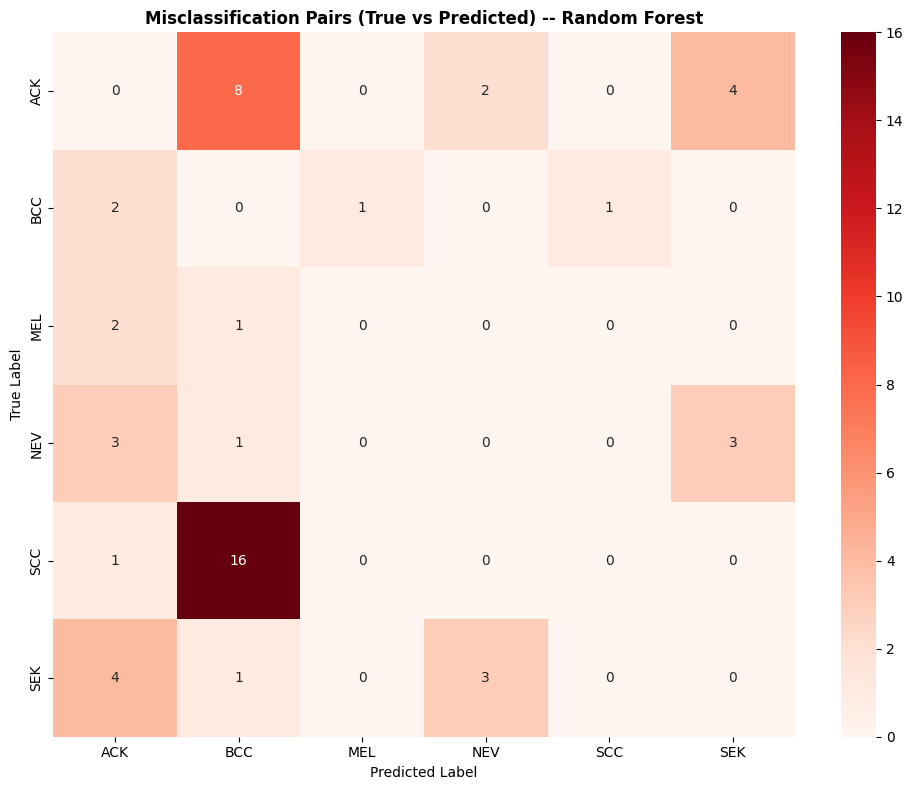

In [87]:
# --- Feature-level comparison of misclassified vs correctly classified samples ---
numeric_cols = x_test.select_dtypes(include=[np.number]).columns
feature_compare_df = pd.DataFrame({
    'Misclassified (mean)': misclassified_df[numeric_cols].mean(),
    'Correctly Classified (mean)': correct_df[numeric_cols].mean(),
})
feature_compare_df['Difference'] = feature_compare_df['Misclassified (mean)'] - feature_compare_df['Correctly Classified (mean)']
print(feature_compare_df.sort_values('Difference', key=abs, ascending=False).round(3).to_string())

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_pairs.unstack(fill_value=0), annot=True, fmt='g', cmap='Reds')
plt.title(f'Misclassification Pairs (True vs Predicted) -- {best_model_name}', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


## 20. CLASS IMBALANCE HANDLING
**Requirement addressed: #8 - Class Imbalance Handling (SMOTE, Class Weights, Balanced Random Forest)**

The dataset is imbalanced (MEL ~2.3%, SCC ~8.4% of samples -- see Section 1). We compare three imbalance-handling strategies against the untouched baseline Random Forest, tracking both overall metrics and recall on the two minority/malignant classes (MEL, SCC), since missing those has the highest clinical cost even if it doesn't help overall accuracy.

In [88]:
# --- Compare imbalance-handling strategies (baseline vs SMOTE vs class_weight vs BalancedRF) ---
print("Comparing class-imbalance handling strategies against the baseline Random Forest...\n")

print("Original training class distribution:")
print(pd.Series(target).map(dict(enumerate(le_target.classes_))).value_counts())

smote = SMOTE(random_state=seed)
x_smote, y_smote = smote.fit_resample(x_scaled, target)
print("\nClass distribution after SMOTE oversampling:")
print(pd.Series(y_smote).map(dict(enumerate(le_target.classes_))).value_counts())

mel_idx = list(le_target.classes_).index('MEL')
scc_idx = list(le_target.classes_).index('SCC')

def eval_imbalance_strategy(name, model, X_fit, y_fit):
    model.fit(X_fit, y_fit)
    pred = model.predict(x_test_scaled)
    per_class_recall = recall_score(target_test, pred, average=None, zero_division=0)
    return {
        'Strategy': name,
        'Accuracy': accuracy_score(target_test, pred),
        'Macro Precision': precision_score(target_test, pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(target_test, pred, average='macro', zero_division=0),
        'Macro F1': f1_score(target_test, pred, average='macro', zero_division=0),
        'MEL Recall': per_class_recall[mel_idx],
        'SCC Recall': per_class_recall[scc_idx],
    }

baseline_rf = clone(rf_model)
smote_rf = clone(rf_model)
weighted_rf = clone(rf_model).set_params(class_weight='balanced')
balanced_rf = BalancedRandomForestClassifier(random_state=seed, n_estimators=200, n_jobs=-1,
                                              sampling_strategy='all', replacement=True, bootstrap=False)

imbalance_results = [
    eval_imbalance_strategy('Baseline RF (no resampling)', baseline_rf, x_scaled, target),
    eval_imbalance_strategy('RF + SMOTE oversampling', smote_rf, x_smote, y_smote),
    eval_imbalance_strategy('RF + class_weight="balanced"', weighted_rf, x_scaled, target),
    eval_imbalance_strategy('Balanced Random Forest (imblearn)', balanced_rf, x_scaled, target),
]

imbalance_df = pd.DataFrame(imbalance_results)
print("\n", imbalance_df.round(4).to_string(index=False))


Comparing class-imbalance handling strategies against the baseline Random Forest...

Original training class distribution:
diagnostic
BCC    591
ACK    511
NEV    171
SEK    165
SCC    134
MEL     36
Name: count, dtype: int64

Class distribution after SMOTE oversampling:
diagnostic
ACK    591
BCC    591
NEV    591
SEK    591
SCC    591
MEL    591
Name: count, dtype: int64

                          Strategy  Accuracy  Macro Precision  Macro Recall  Macro F1  MEL Recall  SCC Recall
      Baseline RF (no resampling)    0.8464           0.8526        0.7435    0.7782      0.6250      0.4138
          RF + SMOTE oversampling    0.8232           0.7533        0.7400    0.7444      0.6250      0.4483
     RF + class_weight="balanced"    0.8493           0.8666        0.7449    0.7815      0.6250      0.4138
Balanced Random Forest (imblearn)    0.7333           0.6549        0.7433    0.6692      0.6250      0.7586


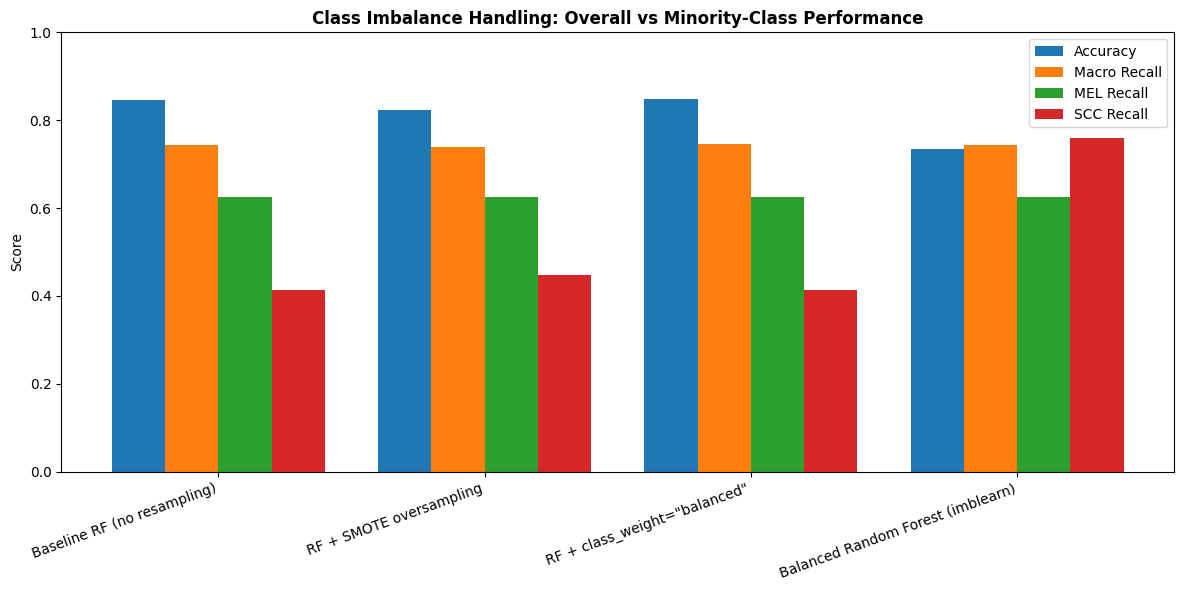

Strategy with highest macro recall (best for minority classes): RF + class_weight="balanced"
Strategy with highest overall accuracy: RF + class_weight="balanced"


In [89]:
# --- Visualize overall vs minority-class performance across strategies ---
plt.figure(figsize=(12, 6))
x_idx = np.arange(len(imbalance_df))
width = 0.2
plt.bar(x_idx - 1.5 * width, imbalance_df['Accuracy'], width, label='Accuracy')
plt.bar(x_idx - 0.5 * width, imbalance_df['Macro Recall'], width, label='Macro Recall')
plt.bar(x_idx + 0.5 * width, imbalance_df['MEL Recall'], width, label='MEL Recall')
plt.bar(x_idx + 1.5 * width, imbalance_df['SCC Recall'], width, label='SCC Recall')
plt.xticks(x_idx, imbalance_df['Strategy'], rotation=20, ha='right')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Class Imbalance Handling: Overall vs Minority-Class Performance', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

best_recall_strategy = imbalance_df.loc[imbalance_df['Macro Recall'].idxmax(), 'Strategy']
best_acc_strategy = imbalance_df.loc[imbalance_df['Accuracy'].idxmax(), 'Strategy']
print(f"Strategy with highest macro recall (best for minority classes): {best_recall_strategy}")
print(f"Strategy with highest overall accuracy: {best_acc_strategy}")
